 # Phần 1: Khảo Sát Dữ Liệu (Exploratory Data Analysis — EDA)

## 1. Kiểm tra chất lượng dữ liệu cơ bản

### 1.1. Thống kê mô tả

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt style cho đồ thị
sns.set_theme(style="whitegrid")

# Load dữ liệu
df = pd.read_csv('data/AmesHousing.csv')

# Loại bỏ khoảng trắng thừa trong tên cột
df.columns = df.columns.str.strip()

print(f"Kích thước bộ dữ liệu: {df.shape}")

# Thống kê mô tả (mean, median, std, min, max, quartiles)
display(df.describe())

# Xem qua các biến phân loại
display(df.describe(exclude='number'))

### 1.2. Kiểm tra dữ liệu trùng lắp

In [ ]:
num_duplicates = df.duplicated().sum()
print(f"Số lượng dòng dữ liệu bị trùng lắp (Duplicates): {num_duplicates}")

#### Nhận xét: Kiểm tra dữ liệu trùng lắp
Qua hàm `duplicated()`, ta thấy bộ dữ liệu Ames Housing không có dòng dữ liệu nào bị trùng lắp hoàn toàn (0 duplicates). Điều này chứng tỏ khâu thu thập dữ liệu gốc đã được quản lý định danh (thông qua mã PID của từng căn nhà) rất tốt. Do đó, nhóm không cần thực hiện bước xóa dòng trùng (drop duplicates) trong quá trình tiền xử lý.

## 2. Trực quan hóa dữ liệu (Histogram & Boxplot)

### 2.1. Khảo sát Biến mục tiêu (SalePrice)

In [ ]:
from scipy.stats import norm

# Thiết kế biểu đồ phân tích cho biến mục tiêu
plt.figure(figsize=(12, 6))

# Vẽ Histogram kết hợp đường KDE
sns.histplot(df['SalePrice'], kde=True, stat="density", color="salmon", bins=50)

# Chèn thêm đường cong phân phối chuẩn (Normal Distribution) để so sánh độ lệch
mu, std = norm.fit(df['SalePrice'].dropna())
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, linestyle='--', label=rf'Normal Dist. ($\mu$={mu:.0f}, $\sigma$={std:.0f})')

plt.title('Phân phối của biến mục tiêu: SalePrice', fontsize=16)
plt.xlabel('Giá bán (USD)', fontsize=12)
plt.ylabel('Mật độ (Density)', fontsize=12)
plt.legend()
plt.show()

# Vẽ Boxplot cho SalePrice để soi outliers của y
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['SalePrice'], color='salmon')
plt.title('Boxplot của SalePrice', fontsize=14)
plt.show()

#### Nhận xét về Biến mục tiêu (Target Variable Analysis)
* **Phân phối:** Biểu đồ Histogram cho thấy `SalePrice` bị lệch phải (Right-skewed) rõ rệt. Đỉnh của phân phối tập trung ở khoảng 130,000 - 160,000 USD, nhưng có một dải đuôi dài kéo về phía các mức giá cao (trên 500,000 USD).
* **So sánh với Phân phối chuẩn:** Đường cong thực tế (Salmon) lệch đáng kể so với đường lý thuyết (Black dashed), cho thấy dữ liệu không tuân theo phân phối chuẩn.
* **Outliers:** Boxplot xác nhận sự tồn tại của nhiều giá trị ngoại lệ ở phía cận trên (giá cao).
* **Kết luận cho OLS:** Để thỏa mãn giả định về phân phối chuẩn của phần dư trong mô hình OLS, việc áp dụng phép biến đổi **Log-transformation** cho `SalePrice` là bắt buộc trước khi đưa vào huấn luyện.

### 2.2. Khảo sát Biến dự báo (Predictors)

In [ ]:
# Tìm các biến có tương quan cao nhất với SalePrice để ưu tiên khảo sát
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

# Lấy top 30 biến tương quan mạnh nhất với SalePrice
top_30_features = corr_matrix['SalePrice'].sort_values(ascending=False).head(30).index

# Định nghĩa danh sách các biến mang tính chất thời gian (năm/tháng)
temporal_cols = ['Year Built', 'Year Remod/Add', 'Garage Yr Blt', 'Yr Sold', 'Mo Sold']

# Lọc ra top các biến tương quan cao, bỏ qua biến mục tiêu (index 0)
# và bỏ qua các biến nằm trong danh sách temporal_cols
predictors_to_plot = [col for col in top_30_features[1:] if col not in temporal_cols][:12]

print(f"12 biến được chọn để vẽ phân phối: {predictors_to_plot}")

# Vẽ lưới Histogram 3x4
plt.figure(figsize=(20, 15))
for i, col in enumerate(predictors_to_plot, 1):
    plt.subplot(3, 4, i)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Phân phối của {col}', fontsize=14)
    plt.xlabel(col, fontsize=12, fontweight='bold')
    plt.ylabel('Tần suất', fontsize=12)
plt.tight_layout()
plt.show()

# Vẽ lưới Boxplot 3x4
plt.figure(figsize=(20, 15))
for i, col in enumerate(predictors_to_plot, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Boxplot của {col}', fontsize=14)
    plt.ylabel('Giá trị', fontsize=12)
    plt.xlabel(col, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

#### Nhận xét về Phân phối của các Biến dự báo
Qua quan sát biểu đồ Histogram của 12 biến độc lập quan trọng nhất, ta rút ra các đặc điểm sau:

* **Các biến đo lường diện tích (`Gr Liv Area`, `Total Bsmt SF`, `1st Flr SF`):** Hầu hết đều có xu hướng lệch phải (Right-skewed). Điều này phản ánh thực tế cấu trúc nhà ở: đại đa số là nhà có diện tích trung bình, chỉ một thiểu số ít là các dinh thự hoặc nhà có diện tích cực lớn.
* **Các biến đánh giá chất lượng (`Overall Qual`, `Garage Cars`, `Full Bath`):** Có dạng phân phối đa đỉnh (Multimodal) hoặc phân bố theo cụm rời rạc. Đây là đặc trưng hiển nhiên của các biến mang tính chất thứ bậc (Ordinal) hoặc số đếm (Count).
* **Đề xuất xử lý:** Sự lệch phải của các biến diện tích có thể làm tăng phương sai của phần dư trong mô hình OLS. Nhóm sẽ cân nhắc áp dụng phép biến đổi Logarit (Log-transform) cho các biến số học liên tục bị lệch nặng để đưa chúng về dạng chuẩn hơn trong bước Pipeline.

#### Nhận xét về Giá trị ngoại lệ (Visual Outliers) của các Biến dự báo
Qua quan sát hình dáng biểu đồ Boxplot, ta nhận thấy sự xuất hiện của rất nhiều điểm ngoại lệ (các chấm đen nằm ngoài râu của đồ thị):

* **Các điểm đòn bẩy tiềm năng (Potential Leverage Points):** Dễ thấy nhất ở biến `Gr Liv Area` và `Total Bsmt SF`. Có những quan sát nằm tách biệt hoàn toàn ở phía trên đỉnh đồ thị (đại diện cho các căn nhà có diện tích cực lớn). Trong lý thuyết OLS, đây là những điểm có nguy cơ trở thành "đòn bẩy", kéo lệch đường hồi quy của toàn bộ tập dữ liệu.
* **Các biến tiện ích đặc thù:** Những biến như `Mas Vnr Area` (Diện tích ốp gạch/đá) hay `Wood Deck SF` (Diện tích sàn gỗ) có mật độ điểm ngoại lệ rất dày đặc. Lý do trực quan là phần lớn các căn nhà không có tiện ích này (giá trị = 0), khiến phần thân hộp (hộp chứa 50% dữ liệu) bị bóp nghẹt lại, đẩy các giá trị > 0 ra ngoài khoảng râu đồ thị.
* **Định hướng bước tiếp theo:** Từ những quan sát trực quan này, nhóm sẽ tiến hành định lượng cụ thể số lượng ngoại lệ bằng công thức thống kê ở phần "Phân tích chuyên sâu" bên dưới để có cơ sở đưa ra thuật toán xử lý (Winsorization) trong `DataPipeline`.

### 2.3. Đánh giá mức độ tương quan (Heatmap)

In [ ]:
# Lấy top 15 biến có độ tương quan cao nhất với SalePrice
top_15_features = corr_matrix['SalePrice'].sort_values(ascending=False).head(15).index
top_15_corr = df[top_15_features].corr()

# Vẽ Clustermap để thuật toán tự động gom các biến đa cộng tuyến lại gần nhau
cluster = sns.clustermap(top_15_corr,
                         annot=True,
                         fmt=".2f",
                         cmap='coolwarm',
                         linewidths=0.5,
                         figsize=(12, 10), # Clustermap dùng figsize bên trong hàm
                         annot_kws={"size": 10},
                         tree_kws={"linewidths": 1.5}) # Làm nét đường cây phân cụm

cluster.fig.suptitle('Ma trận tương quan phân cụm (Clustermap) của 15 biến quan trọng', fontsize=16, y=1.05)

plt.setp(cluster.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
plt.setp(cluster.ax_heatmap.get_yticklabels(), rotation=0)

plt.show()

#### Nhận xét về Ma trận tương quan phân cụm (Clustermap)
Thay vì sắp xếp thủ công, nhóm sử dụng thuật toán Phân cụm phân cấp (Hierarchical Clustering) thông qua biểu đồ Clustermap để máy tính **tự động** tính toán khoảng cách và gom nhóm các biến có độ tương quan cao lại với nhau. Qua quan sát, ta rút ra các kết luận quan trọng:

* **Các biến dự báo "át chủ bài":** `Overall Qual` (Chất lượng tổng thể) và `Gr Liv Area` (Diện tích sinh hoạt) đã khẳng định vị thế là 2 biến độc lập có tác động mạnh mẽ nhất đến `SalePrice`. Đây sẽ là các biến mang trọng số cao trong phương trình hồi quy.
* **Phát hiện Đa cộng tuyến (Multicollinearity) tự động:** Nhờ cây phân cụm (dendrogram), thuật toán đã nhóm thành công 4 cụm biến (các ô màu đỏ sẫm tạo thành khối vuông) có hiện tượng đa cộng tuyến rất cao:
  1. **`Garage Cars` & `Garage Area`:** Sức chứa (số xe) và diện tích vật lý của gara tỉ lệ thuận trực tiếp với nhau.
  2. **`TotRms AbvGrd` & `Gr Liv Area`:** Tổng số phòng và tổng diện tích sinh hoạt trên mặt đất về cơ bản đang đo lường cùng một quy mô không gian.
  3. **`1st Flr SF` & `Total Bsmt SF`:** Khuôn viên diện tích mặt bằng tầng 1 thường được xây dựng khớp với diện tích tầng hầm bên dưới nó.
  4. **`Year Built` & `Garage Yr Blt`:** Đại đa số gara đều được xây dựng cùng năm với thời điểm cất nhà chính.
* **Đề xuất xử lý cho mô hình OLS:** Hiện tượng đa cộng tuyến sẽ làm ma trận thiết kế bị suy biến và gây nhiễu các hệ số $\beta$. Ở bước `DataPipeline`, nhóm đề xuất sẽ **chỉ giữ lại một biến** trong mỗi cặp để đưa vào huấn luyện. Điển hình như cặp số 4, nhóm sẽ loại bỏ `Garage Yr Blt` (vì cột này chứa 159 giá trị khuyết) và giữ lại `Year Built` nhằm tối ưu hóa bộ dữ liệu.

#### 2.4. Khảo sát tính tuyến tính giữa các Biến độc lập và Biến mục tiêu (SalePrice)

In [ ]:
plt.figure(figsize=(18, 6))

# 1. Gr Liv Area vs SalePrice (Biến diện tích liên tục)
plt.subplot(1, 2, 1)
sns.regplot(data=df, x='Gr Liv Area', y='SalePrice',
            scatter_kws={'alpha':0.5, 's':20},
            line_kws={'color':'red'})
plt.title('Mối quan hệ giữa Diện tích sinh hoạt và Giá bán', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

# 2. Overall Qual vs SalePrice (Biến chất lượng rời rạc)
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Overall Qual', y='SalePrice', hue='Overall Qual', palette='viridis', legend=False)
plt.title('Mối quan hệ giữa Chất lượng tổng thể và Giá bán', fontsize=14)

plt.tight_layout()
plt.show()

#### Nhận xét về tính tuyến tính và tương quan
Biểu đồ Scatter Plot và Boxplot kết hợp với đường hồi quy (Red line) cho thấy:

* **Tính tuyến tính:** Biến `Gr Liv Area` thể hiện một mối quan hệ tuyến tính thuận rất rõ rệt với `SalePrice`. Khi diện tích tăng, giá nhà có xu hướng tăng theo một tỉ lệ ổn định. Điều này cho thấy mô hình hồi quy tuyến tính là một lựa chọn hợp lý để thử nghiệm ở bước tiếp theo.
* **Hiện tượng "loe phễu":** Ở biểu đồ bên trái, ta thấy khi diện tích càng lớn, các điểm dữ liệu càng phân tán rộng hơn (hình cái loa). Đây là dấu hiệu của phương sai thay đổi (Heteroscedasticity), củng cố thêm lý do tại sao nhóm cần áp dụng Log-transform ở bước sau để "nén" phương sai này lại.
* **Biến chất lượng:** Với `Overall Qual`, giá nhà tăng theo bậc thang khi chất lượng tăng. Tuy nhiên, ở các mức chất lượng cao nhất (9 và 10), sự biến động về giá là cực lớn, cho thấy chất lượng chỉ là điều kiện cần, còn giá cuối cùng phụ thuộc thêm nhiều yếu tố khác.

## 3. Phân tích chuyên sâu

### 3.1. Phân tích Missing Values

In [ ]:
import missingno as msno
import matplotlib.pyplot as plt

# Thống kê số lượng và tỷ lệ missing
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_report = pd.DataFrame({'Số lượng': missing, 'Tỷ lệ %': missing_pct})
missing_report = missing_report[missing_report['Số lượng'] > 0].sort_values('Tỷ lệ %', ascending=False)
print(f"Có {len(missing_report)} biến bị missing:\n")
display(missing_report)

# Chỉ vẽ các cột có missing
missing_cols = df.columns[df.isnull().any()].tolist()
if missing_cols:
    msno.bar(df[missing_cols], figsize=(12, 5), fontsize=10)
    plt.title("Tỷ lệ missing values")
    plt.show()
else:
    print("Không có cột nào bị missing.")

### Phân tích tổng quan dữ liệu khuyết (Missing Values)

Thay vì liệt kê đơn lẻ, việc phân tích dữ liệu khuyết được nhóm chia thành các cụm đặc trưng có cùng bản chất nghiệp vụ để dễ dàng nhận diện pattern (quy luật bị khuyết). Trực quan hóa dữ liệu cho thấy các giá trị `NaN` không phân bố ngẫu nhiên mà tập trung vào 3 nhóm chính:

1. **Nhóm khuyết diện rộng (> 80%):** Bao gồm `Pool QC` (99.5%), `Misc Feature` (96.3%), `Alley` (93.2%), `Fence` (80.4%). Đây là các tiện ích "xa xỉ" hoặc không phổ biến. Tỉ lệ khuyết cao phản ánh thực tế phần lớn các ngôi nhà không sở hữu các tiện ích này.
2. **Nhóm khuyết theo cụm cấu trúc (Structural Clusters - ~2.5% đến 5%):**
   - **Cụm Garage:** Các biến `Garage Type`, `Garage Finish`, `Garage Qual`, `Garage Cond`, `Garage Yr Blt` luôn bị khuyết cùng lúc trên cùng các dòng dữ liệu.
   - **Cụm Basement (Tầng hầm):** Tương tự, `Bsmt Qual`, `Bsmt Cond`, `Bsmt Exposure`, `BsmtFin Type 1/2` có pattern khuyết đồng thời.
   $\rightarrow$ Trạng thái khuyết này có tính hệ thống cao, đại diện cho việc ngôi nhà hoàn toàn không có Gara hoặc Tầng hầm.
3. **Nhóm khuyết rời rạc (MAR / Lỗi nhập liệu):** - `Lot Frontage` (~16.7%): Mọi lô đất đều phải có mặt tiền tiếp giáp, việc khuyết dữ liệu có thể do khó khăn trong việc đo đạc ở một số khu vực nhất định.
   - `Mas Vnr Type / Area` và `Electrical`: Tỉ lệ khuyết rất nhỏ, mang dấu vết của sự bỏ sót ngẫu nhiên trong quá trình số hóa dữ liệu.

*Nhận định:* Phần lớn dữ liệu khuyết trong tập Ames Housing chứa đựng **thông tin nghiệp vụ quan trọng** (nhà không có tiện ích) thay vì lỗi thu thập. Do đó, tuyệt đối không được dùng phương pháp xóa dòng (Listwise Deletion) để tránh mất mát thông tin nghiêm trọng.

### 3.2. Phát hiện Outliers bằng phương pháp IQR

In [ ]:
# 1. ĐỊNH LƯỢNG OUTLIERS BẰNG PHƯƠNG PHÁP IQR
outlier_counts = {}
iqr_zero_cols = []

def count_outliers_iqr_advanced(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1

    # Bắt lỗi: Nếu IQR = 0, phương pháp này trở nên vô nghĩa
    if IQR == 0:
        return -1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = dataframe[(dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)]
    return len(outliers)

# Quét qua toàn bộ các cột numeric
for col in numeric_cols:
    count = count_outliers_iqr_advanced(df, col)
    if count == -1:
        iqr_zero_cols.append(col)
    else:
        outlier_counts[col] = count

# Hiển thị bảng Outliers hợp lệ
outliers_df = pd.DataFrame(list(outlier_counts.items()), columns=['Biến (Feature)', 'Số lượng Outliers'])
outliers_df['Tỉ lệ (%)'] = (outliers_df['Số lượng Outliers'] / len(df)) * 100
outliers_df = outliers_df[outliers_df['Số lượng Outliers'] > 0].sort_values(by='Số lượng Outliers', ascending=False)

print("BẢNG THỐNG KÊ OUTLIERS HỢP LỆ (IQR > 0)")
display(outliers_df.head(10))

print("\nDANH SÁCH CÁC BIẾN KHÔNG THỂ ÁP DỤNG IQR (IQR = 0)")
print(f"Tổng cộng có {len(iqr_zero_cols)} biến. Danh sách chi tiết:")
print(iqr_zero_cols)

# 2. XÁC ĐỊNH ĐIỂM ĐÒN BẨY CỰC ĐOAN
leverage_candidates = df[(df['Gr Liv Area'] > 4000) & (df['SalePrice'] < 300000)]
print(f"\nĐIỂM ĐÒN BẨY TIỀM NĂNG (Gr Liv Area > 4000 & SalePrice < 300k): {len(leverage_candidates)} quan sát")

#### Nhận xét về Giá trị ngoại lệ & Giới hạn của phương pháp IQR
Trong quá trình định lượng Outliers, nhóm phát hiện một vấn đề mang tính nền tảng của thuật toán IQR: Có nhiều biến sở hữu khoảng tứ phân vị bằng 0 ($IQR = 0$). Nhóm đã tiến hành lọc riêng các biến này ra khỏi bảng thống kê và phân loại thành 2 nhóm bản chất:

1. **Nhóm dữ liệu thưa thớt (Zero-inflated):** Tiêu biểu là `BsmtFin SF 2`, `Enclosed Porch`, `Screen Porch`. Hơn 80% giá trị của các biến này là 0 (nhà không có tiện ích này). Khi $Q1 = 0$ và $Q3 = 0$, mọi giá trị $> 0$ đều bị IQR kết luận là ngoại lệ. Điều này là **vô lý về mặt nghiệp vụ**, vì việc có một cái hiên nhà không thể bị coi là điểm dị thường.
2. **Nhóm dữ liệu thiếu phương sai (Near-constant):** Tiêu biểu là `Kitchen AbvGr`. 99% các căn nhà có đúng 1 nhà bếp ($Q1 = 1, Q3 = 1$). Những căn có 2 bếp sẽ bị IQR bắt lỗi. Thực chất đây là những căn hộ thiết kế đặc biệt (nhà ghép/duplex), việc áp dụng công thức khoảng cách cho biến gần như hằng số này là **không phù hợp**.

**Định hướng xử lý trong Pipeline:**
* **Đối với các biến có IQR bình thường (như `SalePrice`, `Gr Liv Area`):** Nhóm sẽ áp dụng kỹ thuật **Winsorization** (chặn phân vị 1% - 99%) để giảm sát thương của các điểm đòn bẩy.
* **Đối với nhóm $IQR = 0$:** Nhóm hoàn toàn **không áp dụng kỹ thuật gọt Outliers**. Thay vào đó, nếu cần thiết, nhóm sẽ xem xét chuyển đổi chúng thành biến phân loại nhị phân (ví dụ: `Has_Enclosed_Porch`: 1/0) để đưa vào mô hình hiệu quả hơn.

#### Nhận xét về Điểm đòn bẩy
Các điểm có Gr Liv Area > 4000 nhưng SalePrice < 300k là bất thường so với xu hướng chung — diện tích lớn nhưng giá lại thấp. Trong OLS, những điểm này có thể trở thành leverage points làm lệch đường hồi quy. Sẽ được loại khỏi tập train trong DataPipeline.

# Phần 2: Tiền xử lý missing values + Feature Engineering

## 2.1. Phân tích cơ chế Missing Values và Kỹ thuật Xử lý

Không phải mọi giá trị thiếu đều có cùng bản chất. Trước khi chọn kỹ thuật xử lý, cần xác định **cơ chế khuyết** (missing mechanism) của từng nhóm biến, vì chọn sai kỹ thuật sẽ tạo ra dữ liệu mâu thuẫn logic và làm sai lệch mô hình.

---

#### Nhóm 1 — Biến định danh và near-zero variance (DROP)

`Order` và `PID` là số thứ tự và mã định danh, unique mỗi hàng — không mang thông tin dự báo, cần drop trước mọi bước xử lý.

`Utilities` (99.9% = `AllPub`) và `Street` (99.6% = `Pave`) gần như hằng số — không phân biệt được các ngôi nhà với nhau, đưa vào mô hình chỉ tạo nhiễu.

**Kỹ thuật: Drop hoàn toàn.**

---

#### Nhóm 2 — Biến >80% missing: MNAR có cấu trúc (DROP + tạo cờ)

`Pool QC` (99.6%), `Misc Feature` (96.4%), `Alley` (93.2%), `Fence` (80.5%) — tỷ lệ missing quá cao không phải do lỗi ghi chép mà vì đại đa số nhà thực sự **không có** những tiện ích này. Đây là **MNAR (Missing Not At Random)** có cấu trúc.

Tuy nhiên thông tin "có hay không" vẫn có giá trị dự báo, nên trước khi drop cần tạo biến cờ: `Has_Pool`, `Has_Alley`, `Has_Fence`, `Has_Misc_Feature`.

**Kỹ thuật: Tạo cờ binary → Drop cột gốc.**

---

#### Nhóm 3 — Garage: MNAR có cấu trúc + MAR

Khi xác định nhà có garage hay không, **không thể chỉ dựa vào một cột**. Đối chiếu chéo 3 cột (`Garage Type`, `Garage Area`, `Garage Cars`) cho thấy 157 nhà không có garage, và tất cả biến garage của nhóm này đều null đồng bộ — đây là **MNAR**: nhà không có garage thì không có năm xây, diện tích, chất lượng garage.

Vấn đề điển hình: nếu áp dụng khuôn mẫu "biến số → điền median", `Garage Yr Blt` của 157 nhà không có garage sẽ được điền ~1979 — mâu thuẫn hoàn toàn với `Garage Type = 'None'`. Mô hình OLS sẽ nhận tín hiệu nhiễu: nhà không có garage nhưng lại có năm xây garage.

**Các trường hợp cần xử lý:**

| Trường hợp | Số lượng | Cơ chế | Kỹ thuật |
|------------|----------|--------|-----------|
| Không có garage | 157 hàng | MNAR | Gán `'None'` cho `Garage Type` và các biến categorical, `0` cho `Garage Cars` và `Garage Area`, giữ `NaN` cho `Garage Yr Blt` |
| Có garage, thiếu `Garage Yr Blt` | 2 hàng | MAR | Median theo nhóm (thập niên `Year Built` × `Garage Type`), fallback theo `Garage Type`, fallback toàn cục |
| Có garage, thiếu `Garage Area` | 1 hàng | MAR | Median theo `Garage Type` |
| Có garage, thiếu `Garage Cars` | 1 hàng | MAR | Median theo nhóm diện tích `Garage Area` (chỉ dùng dòng có `Garage Cars > 0` và `Garage Area > 0` để tính bins) |
| Có garage, thiếu `Garage Type` (do `Area/Cars > 0` nhưng `Type` bỏ trống) | edge case | MAR | Mode theo nhóm diện tích `Garage Area` (chỉ dùng dòng có `Garage Type` đã biết để tính bins, tránh index mismatch) |
| `Garage Type = 'Attchd'` có `Garage Yr Blt < Year Built` | 5 hàng | Lỗi nhập liệu | Sửa `Garage Yr Blt = Year Built` (garage đính kèm không thể xây trước nhà) |
| `Garage Finish`, `Garage Qual`, `Garage Cond` | 159 hàng mỗi biến | MAR | Mode theo nhóm (`Garage Type` × `Overall Qual`), fallback theo `Garage Type` |

**Kỹ thuật xử lý `Garage Yr Blt`:**
- Nhà không có garage: giữ `NaN` (không gán giá trị vì feature không tồn tại).
- Nhà có garage nhưng missing (2 hàng MAR): median theo nhóm thập niên × loại garage.
- Sau xử lý, `Garage Yr Blt` chỉ còn `NaN` ở nhóm không có garage — sẽ được xử lý tiếp trong Feature Engineering (tạo `Has_Garage` và `Garage_Age`).
- Kiểm tra thêm ở Bước 5: nếu `Garage Yr Blt > Yr Sold` (lỗi nhập liệu rõ ràng) thì gán lại bằng `Year Built`.

---

#### Nhóm 4 — Basement: MNAR + MAR

80 nhà không có tầng hầm (anchor: `Total Bsmt SF = 0` hoặc tổng diện tích các phần = 0). Toàn bộ biến basement của nhóm này đều là **MNAR**.

Tuy nhiên có một số hàng null trong khi nhà **có** tầng hầm — đây là **MAR** (lỗi bỏ sót khi ghi chép), cần xử lý riêng.

**Lưu ý thứ tự xử lý:** `Total Bsmt SF` và `Bsmt Unf SF` có quan hệ kế toán (`Total = Fin1 + Fin2 + Unf`). Phải xử lý theo đúng thứ tự nhân quả:
1. Tính `Total Bsmt SF` trước (từ tổng các phần, dùng `fillna(0)` để tránh NaN propagation)
2. Tính `Bsmt Unf SF` sau (phần dư = `Total - Fin1 - Fin2`)

Đảo thứ tự sẽ gây NaN propagation: `NaN - 500 - 0 = NaN`.

| Biến                                         | Số lượng MAR | Kỹ thuật |
|----------------------------------------------|--------------|--------|
| `Bsmt Exposure`                              | 3 hàng       | Mode theo `BsmtFin Type 1` của nhà có tầng hầm (`notna()` filter); fallback global mode nếu Type không có trong lookup |
| `BsmtFin Type 2`                             | 1 hàng       | Mode của nhà có `BsmtFin SF 2 > 0` |
| `BsmtFin SF 1`                               | 1 hàng       | Median theo `BsmtFin Type 1` (chỉ dùng dòng có `SF > 0`) |
| `BsmtFin SF 2`                               | 1 hàng       | Median theo `BsmtFin Type 2` (chỉ dùng dòng có `SF > 0`) |
| `BsmtFin Type 1/2` (SF = 0, Type null)       | một số hàng | Gán thẳng `'Unf'` — diện tích = 0 thì loại hoàn thiện chắc chắn là chưa hoàn thiện (logic, không phải imputation) |
| `BsmtFin Type 1/2` (biết SF > 0, thiếu Type) | một số hàng  | Mode theo nhóm diện tích SF (bins tính từ dòng có `SF > 0` và có tầng hầm, tránh giá trị 0 kéo lệch ranh giới nhóm) |
| `Bsmt Unf SF`                                | 1 hàng       | Tính từ phần dư: `Total Bsmt SF - Fin1 - Fin2` (quan hệ kế toán) |
| `Total Bsmt SF`                              | 1 hàng       | Tính từ tổng: `Fin1 + Fin2 + Unf` |
| `Bsmt Full Bath`                             | 2 hàng       | Điền `0` (tầng hầm không bắt buộc có phòng tắm) |
| `Bsmt Half Bath`                             | 2 hàng       | Điền `0` |
| `Bsmt Qual`                                  | 80 hàng      | Mode theo nhóm quantile `Total Bsmt SF` (tương quan r=0.46); bins tính từ dòng có tầng hầm và `SF > 0` |
| `Bsmt Cond`                                  | 80 hàng      | Mode theo thập niên `Year Built` — nhà trước 1900 có tỷ lệ `'Fa'` lên đến 28–33%, khác biệt đáng kể so với global mode 89% là `'TA'`; fallback `'TA'` |

---

#### Nhóm 5 — Fireplace Qu: MNAR thuần túy

1,422 hàng (48.5%) `Fireplace Qu = NaN` khi `Fireplaces = 0` — 100% khớp, không có ngoại lệ. Không có lò sưởi thì không có chất lượng lò sưởi. Đây là **MNAR** rõ ràng nhất trong dataset.

Kiểm tra data thực tế xác nhận: không có hàng nào `Fireplaces > 0` mà `Fireplace Qu = NaN`, do đó **không cần imputation cho nhóm MAR**.

**Kỹ thuật: `Fireplaces = 0` → điền `'None'`.** Pipeline được thiết kế phòng thủ (defensive): nếu trong tương lai xuất hiện trường hợp MAR (nhà có lò sưởi nhưng thiếu `Fireplace Qu`), tự động điền mode theo nhóm `(Overall Qual, Bldg Type)` — phản ánh thực tế là chất lượng lò sưởi phụ thuộc vào chất lượng tổng thể và loại nhà.

---

#### Nhóm 6 — Mas Vnr (Lớp ốp đá/gạch): MNAR + MAR nhỏ

1,775 hàng (60.6%) `Mas Vnr Type = NaN` — phần lớn là nhà không có lớp ốp đá (**MNAR**). Anchor được xác định bằng đối chiếu chéo: `Mas Vnr Area > 0` HOẶC `Mas Vnr Type ≠ NaN và ≠ 'None'`.

7 hàng có diện tích ốp đá > 0 nhưng thiếu loại (`Mas Vnr Type = NaN`) — **MAR** (lỗi nhập liệu). Không thể điền mode toàn tập vì phân phối loại ốp đá phụ thuộc diện tích: diện tích nhỏ thường là `BrkFace`, lớn thường là `Stone`. Bins cố định `[0, 100, 300, 10000]` được chọn dựa trên đặc tính vật lý của từng loại vật liệu.

**Kỹ thuật:**
- MNAR (1,768 hàng): điền `'None'` / `0`
- MAR — 7 hàng thiếu `Mas Vnr Type`: mode theo nhóm diện tích (small/medium/large)
- Thiếu `Mas Vnr Area` khi có ốp đá: không xuất hiện trong dataset này (0 hàng); pipeline xử lý phòng thủ bằng median theo loại `Mas Vnr Type` nếu gặp ở dữ liệu khác

---

#### Nhóm 7 — Lot Frontage: MAR

490 hàng (16.7%) missing. Mọi lô đất đều có mặt tiền — việc thiếu là do **bỏ sót khi đo đạc** → **MAR**. Bằng chứng: tỷ lệ missing thay đổi rõ rệt theo khu vực (`GrnHill`: 100%, `Landmrk`: 100%, `ClearCr`: 54.5%, trong khi nhiều khu vực khác <10%).

Quan trọng hơn, median `Lot Frontage` dao động rất lớn theo neighborhood: từ 21 ft (`BrDale`) đến 92 ft (`NridgHt`), trong khi global median chỉ là 68 ft. Dùng global median sẽ sai lệch lớn cho các khu vực đặc thù.

**Kỹ thuật:** Grouped median theo `Neighborhood`. Fallback bằng global median cho những dòng vẫn missing sau grouped median — thực tế có **3 dòng** phải dùng global median fallback (thuộc các neighborhood quá ít mẫu để tính median).

---

#### Nhóm 8 — Electrical: MCAR

Chỉ 1 hàng missing (0.03%), không có quy luật kết hợp với bất kỳ biến nào — **MCAR** thuần túy. `SBrkr` chiếm 91.5% giá trị.

**Kỹ thuật: Điền mode = `'SBrkr'`.**

---

#### Tóm tắt cơ chế và kỹ thuật

| Nhóm | Biến | Missing | Cơ chế | Kỹ thuật |
|------|------|---------|---------|-----------|
| Định danh / NZV | `Order`, `PID`, `Utilities`, `Street` | — | — | Drop |
| >80% missing | `Pool QC`, `Misc Feature`, `Alley`, `Fence` | 2358–2917 | MNAR | Tạo cờ → Drop |
| Garage (MNAR) | Garage cluster | 157–159 | MNAR | `'None'` / `0` (giữ `NaN` cho `Garage Yr Blt`) |
| Garage (MAR) | `Garage Yr Blt` | 2 | MAR | Median theo thập niên × loại, fallback cascade |
| Garage (MAR) | `Garage Area` | 1 | MAR | Median theo `Garage Type` |
| Garage (MAR) | `Garage Cars` | 1 | MAR | Median theo nhóm diện tích `Garage Area` |
| Garage (MNAR) | `Garage Type` | 157 | MNAR | `'None'` (toàn bộ 157 hàng là nhà không có garage) |
| Garage (MAR) | `Garage Type` (có `Area/Cars > 0` nhưng `Type` bỏ trống) | edge case | MAR | Mode theo nhóm diện tích `Garage Area` |
| Garage quality | `Finish`, `Qual`, `Cond` | 159 | MAR | Mode theo `Garage Type` × `Overall Qual`, fallback cascade |
| Basement (MNAR) | Basement cluster | 80–83 | MNAR | `'None'` / `0` |
| Basement (MAR) | `Bsmt Exposure` | 3 | MAR | Mode theo `BsmtFin Type 1` của nhà có tầng hầm; fallback global mode |
| Basement (MAR) | `BsmtFin Type 2` | 1 | MAR | Mode nhà có `BsmtFin SF 2 > 0` |
| Basement (MAR) | `BsmtFin SF 1/2` | 1 | MAR | Median theo loại Type (chỉ dùng `SF > 0`) |
| Basement | `BsmtFin Type 1/2` (SF = 0, Type null) | vài hàng | Logic | Gán thẳng `'Unf'` (không phải imputation) |
| Basement (MAR) | `BsmtFin Type 1/2` (SF > 0, thiếu Type) | vài hàng | MAR | Mode theo nhóm diện tích SF |
| Basement | `Total Bsmt SF` | 1 | Kế toán | Tính từ `Fin1 + Fin2 + Unf` (xử lý **trước** `Bsmt Unf SF`) |
| Basement | `Bsmt Unf SF` | 1 | Kế toán | Tính từ `Total - Fin1 - Fin2` (xử lý **sau** `Total Bsmt SF`) |
| Basement | `Bsmt Full/Half Bath` | 2 | MAR | Điền `0` |
| Basement | `Bsmt Qual` | 80 | MAR | Mode theo nhóm quantile `Total Bsmt SF` |
| Basement | `Bsmt Cond` | 80 | MAR | Mode theo thập niên `Year Built`, fallback `'TA'` |
| Fireplace (MNAR) | `Fireplace Qu` | 1422 | MNAR | `'None'` (không cần imputation thêm) |
| Mas Vnr (MNAR) | `Mas Vnr Type` | 1775 | MNAR | `'None'` / `0` |
| Mas Vnr (MAR) | `Mas Vnr Type` | 7 | MAR | Mode theo nhóm diện tích |
| Mas Vnr (MAR) | `Mas Vnr Area` (thiếu Area khi có ốp đá) | 0 (dataset này) | MAR | Median theo loại Type (defensive) |
| Lot Frontage (MAR) | `Lot Frontage` | 490 | MAR | Grouped median theo `Neighborhood`; fallback global median (3 dòng) |
| Electrical (MCAR) | `Electrical` | 1 | MCAR | Mode (`SBrkr`) |

Dựa trên phân tích cơ chế ở trên, nhóm triển khai xử lý missing values trong module `data_pipeline.py`. Toàn bộ logic được xây dựng theo **quan hệ nhân-quả** giữa các biến.

Quy trình tiền xử lí có 6 bước tuần tự: xóa biến vô dụng → kiểm tra tính nhất quán → xử lý missing theo từng nhóm → imputation Lot Frontage & Electrical → tạo biến mới → kiểm tra lần cuối (raise lỗi nếu còn missing).

## 2.2. Feature Engineering (Kỹ nghệ Đặc trưng)

Dựa trên nguyên tắc tối ưu hóa thông tin và giảm nhiễu cho mô hình Hồi quy tuyến tính, nhóm tiến hành biến đổi, gộp và tạo mới các đặc trưng (Features) mang ý nghĩa nghiệp vụ cao hơn:

* **1. Biến thời gian (Temporal Features):**
  * Thay vì sử dụng các mốc năm tuyệt đối gây khó khăn cho thuật toán, nhóm chuyển hóa thành các khoảng thời gian tương đối: `Age_At_Sale` (Tuổi của nhà khi bán) và `Remod_Age` (Số năm từ khi trùng tu đến khi bán).
  * Bổ sung biến cờ `Was_Remodeled` (1/0) để đánh dấu những ngôi nhà đã từng được cải tạo, giúp mô hình nắm bắt được "giá trị cộng thêm" của việc nâng cấp.
* **2. Biến tổng hợp không gian (Aggregated Space/Utility Metrics):**
  * **`Total_Bath`:** Gộp 4 biến phòng tắm rời rạc (Full/Half của tầng nổi và tầng hầm) thành một chỉ số duy nhất, với trọng số hợp lý (Half Bath = 0.5).
  * **`Total_Porch`:** Tính tổng diện tích của tất cả các loại hiên nhà (Open, Enclosed, 3Ssn, Screen) để phản ánh tổng quan không gian thư giãn ngoài trời.
* **3. Biến nhị phân hóa (Binary/Flag Features):**
  * **`Has_Low_Qual_Fin`:** Biến `Low Qual Fin SF` (Diện tích hoàn thiện chất lượng thấp) có tỷ lệ giá trị 0 áp đảo (>90%). Việc giữ nguyên biến số học sẽ tạo ra nhiễu phân phối. Nhóm quyết định nhị phân hóa thành biến cờ (Có/Không có diện tích kém).
  * **`Has_Negative_Condition`:** Nhận diện các vị trí bất lợi làm giảm giá trị bất động sản (như gần đường lớn `Artery` hay đường sắt `RR...`) từ hai cột `Condition 1` và `Condition 2`.
  * **`Is_Normal_Sale`:** Đánh dấu các giao dịch tuân thủ chuẩn thị trường (`Sale Type = WD` và `Sale Condition = Normal`). Biến này giúp mô hình "cảnh giác" với các giao dịch bất thường (phát mãi, nội bộ gia đình) thường có giá bán lệch khỏi quỹ đạo chung.
* **4. Xử lý đặc trưng garage (Garage Features):**
  * Do `Garage Yr Blt` (năm xây garage) là `NaN` đối với những nhà không có garage (MNAR) và gây nhiễu nếu gán 0 hoặc median, nhóm quyết định **không imputation** biến này.
  * Thay vào đó, tạo biến cờ `Has_Garage` (1: có garage, 0: không) và biến `Garage_Age` (tuổi garage = `Yr Sold - Garage Yr Blt` cho nhà có garage, bằng 0 cho nhà không có garage).
  * Sau khi tạo `Garage_Age`, loại bỏ cột `Garage Yr Blt` gốc để tránh đa cộng tuyến và loại `NaN` khỏi mô hình.
  * Các biến garage còn lại (`Garage Finish`, `Garage Qual`, `Garage Cond`) được giữ nguyên sau xử lý missing (gán `'None'` nếu không có garage).
## 2.3. Lựa chọn đặc trưng (Feature Selection & Dimension Reduction)

Để giải quyết triệt để Lời nguyền số chiều (Curse of Dimensionality) và chống Đa cộng tuyến hoàn hảo (Perfect Multicollinearity), sau khi tạo biến mới, nhóm đã chủ động loại bỏ (drop) các tập biến gốc:

* **Nhóm biến thời gian gốc:** Xóa `Year Built`, `Year Remod/Add`, `Yr Sold` (đã được hấp thụ hoàn toàn vào biến Age).
* **Nhóm biến thành phần dư thừa:** Xóa 4 biến gốc của Porch (`Open Porch SF`, `Enclosed Porch`...) và 4 biến gốc của Bathroom (`Full Bath`, `Half Bath`...).
* **Nhóm biến logic phân mảnh:** Xóa `Low Qual Fin SF`, `Condition 1`, `Condition 2` (do đã được chuyển hóa thành các biến cờ tổng hợp mang tính đại diện cao hơn).

# Phần 3: Data Pipeline và VIF

**Mục tiêu:**
- Tổng quan kiến trúc `DataPipeline` và quy trình xử lý dữ liệu
- Chạy Pipeline trên tập train, kiểm tra shape đầu ra
- Phân tích kết quả VIF và lý giải các cột bị loại
- Kiểm tra phân phối dữ liệu sau pipeline


## 3.1. Kiến Trúc DataPipeline

`DataPipeline` được thiết kế theo kiến trúc **Fit → Transform** (tương tự `sklearn`), đảm bảo mọi tham số (Winsorize limits, encoding map, scale params) chỉ được học từ tập **train** — không bao giờ nhìn thấy test set trong quá trình học.

Quy trình xử lý gồm **6 bước tuần tự**:

| Bước | Tên bước | Mô tả |
|------|----------|-------|
| A | **Outlier Treatment** | Winsorize (cắt 5% mỗi đuôi) hoặc Remove theo IQR |
| B | **Feature Engineering** | Tạo `Total_SqFt` = `Gr Liv Area` + `Total Bsmt SF` |
| C | **Ordinal Encoding** | Map thứ bậc chất lượng (`Ex→5`, `Gd→4`, `TA→3`, `Fa→2`, `Po→1`, `None→0`) |
| D | **One-Hot Encoding** | Mã hóa 20 biến danh nghĩa (Neighborhood, BldgType...), `drop_first=True` |
| E | **Log Transform** | `log1p` các cột số có skew > 0.75 (học trên train, apply cả test) |
| F | **Z-score Standardization** | Chuẩn hóa toàn bộ cột số về μ=0, σ=1 |

**Lưu ý chống Data Leakage:** `train_test_split` được thực hiện **trước** khi gọi `fit_transform`, đảm bảo phân phối của test set không ảnh hưởng đến tham số Winsorize và Scale.


In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Điều chỉnh sys.path ─────────────────────────────────────────────
NOTEBOOK_DIR = os.getcwd()
BASE_DIR     = os.path.dirname(NOTEBOOK_DIR)
PART2_DIR    = os.path.join(BASE_DIR, 'part2')
for p in [BASE_DIR, PART2_DIR, NOTEBOOK_DIR]:
    if p not in sys.path:
        sys.path.insert(0, p)

from part2.clean_data      import clean_data
from part2.data_pipeline   import DataPipeline, run_vif_check
from part2.model_comparison import train_test_split_df

DATA_PATH = os.path.join(PART2_DIR, 'data', 'AmesHousing.csv')

# ── Load & clean ────────────────────────────────────────────────────
df_clean = clean_data(DATA_PATH, verbose=False)
print(f'Shape sau clean_data: {df_clean.shape}')

# ── Tách target ─────────────────────────────────────────────────────
y_raw = df_clean['SalePrice']
X_raw = df_clean.drop(columns=['SalePrice'])

# ── Train / Test split 80/20 — TRƯỚC pipeline để tránh leakage ──────
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split_df(
    X_raw, y_raw, test_size=0.2, random_state=42
)
print(f'Train : {X_train_raw.shape[0]} mẫu  |  Test : {X_test_raw.shape[0]} mẫu')
print(f'Số features gốc: {X_raw.shape[1]}')


Shape sau clean_data: (2930, 71)
Train : 2344 mẫu  |  Test : 586 mẫu
Số features gốc: 70


## 3.2. Chạy DataPipeline

Pipeline được cấu hình với các tham số sau:

- **`outlier_method='winsorize'`, `outlier_threshold=0.05`:** Cắt 5% mỗi đuôi cho cả biến liên tục lẫn target. Phương pháp Winsorization được ưu tiên hơn Remove vì bảo toàn số hàng — quan trọng với tập dữ liệu ~2,930 quan sát.
- **`encoding='auto'`:** Tự động phân loại Ordinal/One-hot dựa trên `ORDINAL_MAPS` và `NOMINAL_COLS` đã định nghĩa trong `data_pipeline.py`.
- **`log_target=True`:** Áp dụng `log1p(SalePrice)` trước khi train — khớp với kết luận EDA (phần 2.1) về sự cần thiết của log transform.
- **`log_skewed_features=True`:** Pipeline tự động phát hiện và log1p các cột số có skew > 0.75 trên tập train.
- **`engineer_features=False`, `add_interactions=False`:** Tắt tính năng tạo biến tổng hợp và interaction tại bước này — các mô hình Polynomial/Interaction sẽ tự tạo ở bước huấn luyện (Phần 4).


In [2]:
pipe = DataPipeline(
    outlier_method      = 'winsorize',
    outlier_threshold   = 0.05,
    encoding            = 'auto',
    scale               = True,
    log_target          = True,
    engineer_features   = False,
    log_skewed_features = True,
    add_interactions    = False,
)

X_train, y_train = pipe.fit_transform(X_train_raw, y_train_raw)
X_test           = pipe.transform(X_test_raw)

print(f'\nShape X_train sau pipeline : {X_train.shape}')
print(f'Shape X_test  sau pipeline : {X_test.shape}')
print(f'Số cột log-transformed     : {len(pipe._skewed_cols_to_log)}')
print(f'Số cột ordinal encoded     : {len(pipe._ordinal_cols_)}')
print(f'Số cột one-hot encoded     : {len(pipe._onehot_cols_)}')
print(f'Số dummy columns tạo ra   : {len(pipe._dummy_cols_)}')

pipe.summary()


  [Target] Áp dụng np.log1p(y)
  [Outlier] Học tham số outlier (method='winsorize')...
  [Encoding] Phân loại cột categorical...
  [Scale] Học tham số z-score...
  Shape sau pipeline: (2344, 208)

Shape X_train sau pipeline : (2344, 208)
Shape X_test  sau pipeline : (586, 208)
Số cột log-transformed     : 6
Số cột ordinal encoded     : 17
Số cột one-hot encoded     : 20
Số dummy columns tạo ra   : 158
DataPipeline Summary
  Outlier method      : winsorize
  Winsorize threshold : 0.05 (mỗi đuôi)
  Encoding            : auto
  Ordinal cols        : 17
  One-hot cols        : 20
  One-hot dummies     : 158
  Scale (z-score)     : True
  Scale params learned: 208 cột
  Feature names out   : 208 cột


## 3.3. Phân Tích VIF và Khử Đa Cộng Tuyến

**VIF (Variance Inflation Factor)** đo mức độ đa cộng tuyến của từng biến so với các biến còn lại. Quy tắc ngưỡng:

| Giá trị VIF | Mức độ | Quyết định |
|-------------|--------|------------|
| VIF < 5 | Không có đa cộng tuyến | Giữ lại |
| 5 ≤ VIF < 10 | Đa cộng tuyến trung bình | Theo dõi |
| VIF ≥ 10 | Đa cộng tuyến nghiêm trọng | **Loại bỏ** |
| VIF = ∞ | Đa cộng tuyến hoàn hảo (Perfect MC) | **Loại bỏ ngay** |

Pipeline sử dụng thuật toán **lặp (iterative elimination):** mỗi vòng lặp tính lại VIF cho tất cả cột còn lại, loại cột có VIF cao nhất, rồi lặp lại cho đến khi mọi cột thỏa mãn `VIF ≤ 10`. Phương pháp này chính xác hơn loại một lần vì VIF của một cột thay đổi khi cột khác bị loại.

**Kết nối với phân tích EDA (phần 2.3):** Clustermap đã cảnh báo trước các nhóm cột đa cộng tuyến cao (`Garage Cars` & `Garage Area`, `TotRms AbvGrd` & `Gr Liv Area`, v.v.). Bước VIF ở đây là sự xác nhận định lượng cho các quan sát trực quan đó.


In [3]:
print('VIF TRƯỚC KHI LỌC (Toàn bộ các cột có VIF >= 10):')
vif_before = run_vif_check(X_train)

# 1. Chỉ lọc lấy những dòng có VIF vượt ngưỡng 10
vif_loi = vif_before[vif_before['VIF'] >= 10]

# 2. Sắp xếp giảm dần để thấy rõ những "thủ phạm" nặng nhất ở trên cùng
vif_loi_sorted = vif_loi.sort_values(by='VIF', ascending=False)

# 3. Dùng option_context để ép Jupyter hiển thị tất cả các dòng mà không bị ẩn "..."
import pandas as pd
with pd.option_context('display.max_rows', None):
    display(vif_loi_sorted)

# Thống kê lại
n_high_vif = len(vif_loi)
n_inf_vif  = np.isinf(vif_loi['VIF']).sum()
print(f'\nTổng cột VIF >= 10  : {n_high_vif}')
print(f'Trong đó VIF = inf  : {n_inf_vif}')

VIF TRƯỚC KHI LỌC (Toàn bộ các cột có VIF >= 10):


,feature,VIF
0,Is_Normal_Sale,inf
1,MS SubClass_90,inf
2,Has_Garage,inf
3,Bldg Type_Duplex,inf
4,Exterior 2nd_PreCast,inf
5,Garage Type_None,inf
6,Exterior 1st_PreCast,inf
7,MS Zoning_RL,478.118698
8,MS Zoning_RM,368.901458
9,MS SubClass_20,129.858773



Tổng cột VIF >= 10  : 72
Trong đó VIF = inf  : 7


In [5]:
# ── Chạy iterative VIF elimination ───────────────────────────────
print('\nBắt đầu khử đa cộng tuyến (threshold=10)...')
print('─' * 60)

X_train, dropped_cols = pipe.drop_high_vif(X_train, y_train, threshold=10)  # ← thêm y_train

# Đồng bộ test set — loại đúng những cột đã drop khỏi train
X_test = X_test.drop(columns=dropped_cols)

print(f'\nX_train sau VIF : {X_train.shape}')
print(f'X_test  sau VIF : {X_test.shape}')
print(f'\nDanh sách {len(dropped_cols)} cột bị loại:')
for i, col in enumerate(dropped_cols, 1):
    print(f'  {i:>2}. {col}')



Bắt đầu khử đa cộng tuyến (threshold=10)...
────────────────────────────────────────────────────────────
  [VIF iter 1] Loại 'Is_Normal_Sale' (VIF=inf, p=1.0000, |corr|=0.0000)
  [VIF iter 2] Loại 'House Style_SLvl' (VIF=19.71, p=1.0000, |corr|=0.0034)
  [VIF iter 3] Loại 'MS SubClass_80' (VIF=27.57, p=1.0000, |corr|=0.0100)
  [VIF iter 4] Loại 'Exterior 1st_Plywood' (VIF=24.82, p=1.0000, |corr|=0.0101)
  [VIF iter 5] Loại 'Roof Matl_Tar&Grv' (VIF=27.82, p=1.0000, |corr|=0.0241)
  [VIF iter 6] Loại 'Exterior 2nd_PreCast' (VIF=inf, p=1.0000, |corr|=0.0269)
  [VIF iter 7] Loại 'Exterior 2nd_Plywood' (VIF=10.47, p=1.0000, |corr|=0.0303)
  [VIF iter 8] Loại 'Heating_GasW' (VIF=28.63, p=1.0000, |corr|=0.0345)
  [VIF iter 9] Loại 'MS SubClass_20' (VIF=30.86, p=1.0000, |corr|=0.0445)
  [VIF iter 10] Loại 'MS Zoning_RH' (VIF=28.87, p=1.0000, |corr|=0.0594)
  [VIF iter 11] Loại 'Exterior 2nd_CmentBd' (VIF=33.16, p=1.0000, |corr|=0.0798)
  [VIF iter 12] Loại 'House Style_1.5Unf' (VIF=10.38, p=1

In [6]:
# ── Tính VIF sau khi lọc — kiểm tra không còn cột nào vượt ngưỡng ──
print('VIF SAU KHI LỌC (Các cột vẫn còn VIF >= 10 nếu bị sót):')
vif_after = run_vif_check(X_train)

# 1. Lọc và sắp xếp các cột vẫn còn VIF >= 10
vif_still_high_df = vif_after[vif_after['VIF'] >= 10].sort_values(by='VIF', ascending=False)

# 2. Hiển thị toàn bộ danh sách lỗi không bị cắt dòng
import pandas as pd
with pd.option_context('display.max_rows', None):
    display(vif_still_high_df)

# 3. Đếm số lượng và kiểm tra chốt chặn
still_high = len(vif_still_high_df)
print(f'\nSố cột còn VIF >= 10: {still_high}  ← Phải bằng 0')

# Dừng chương trình nếu vẫn còn cột VIF cao
assert still_high == 0, 'Vẫn còn cột VIF cao! Kiểm tra lại pipeline.'
print('✅ Tất cả cột đều VIF < 10. Pipeline sẵn sàng cho huấn luyện.')


VIF SAU KHI LỌC (Các cột vẫn còn VIF >= 10 nếu bị sót):


,feature,VIF



Số cột còn VIF >= 10: 0  ← Phải bằng 0
✅ Tất cả cột đều VIF < 10. Pipeline sẵn sàng cho huấn luyện.


#### Nhận xét:
- Chiến lược loại bỏ biến hợp lý: Quy trình xử lý không chỉ dựa trên chỉ số VIF mà còn xem xét mức độ tương quan giữa từng biến với biến mục tiêu. Các biến có giá trị dự báo thấp được ưu tiên loại bỏ trước, giúp giảm đa cộng tuyến trong khi vẫn bảo toàn thông tin quan trọng cho mô hình.
- Xử lý hiệu quả đa cộng tuyến hoàn hảo: Nhiều biến có giá trị VIF = ∞ đã được phát hiện và loại bỏ thành công. Điều này cho thấy pipeline đã xử lý tốt các trường hợp phụ thuộc tuyến tính hoàn hảo, thường xuất hiện sau bước One-Hot Encoding.
- Loại bỏ chủ yếu các biến phân loại dư thừa: Các biến bị loại phần lớn là các biến giả (dummy variables) sinh ra từ quá trình mã hóa dữ liệu phân loại. Đây là kết quả phù hợp do nhóm biến này thường chứa thông tin chồng chéo và dễ gây đa cộng tuyến.
- Nâng cao chất lượng dữ liệu đầu vào: Việc loại bỏ các đặc trưng dư thừa giúp giảm số chiều dữ liệu, tăng tính ổn định của các hệ số hồi quy, hạn chế hiện tượng overfitting và cải thiện hiệu quả huấn luyện của các mô hình học máy.

#### Kết luận:
Bước xử lý đa cộng tuyến đã làm sạch dữ liệu hiệu quả, giữ lại các đặc trưng có giá trị dự báo cao và tạo ra bộ dữ liệu đầu vào ổn định hơn cho các giai đoạn mô hình hóa tiếp theo.

## 3.4. Trực Quan Hóa VIF Trước và Sau Lọc


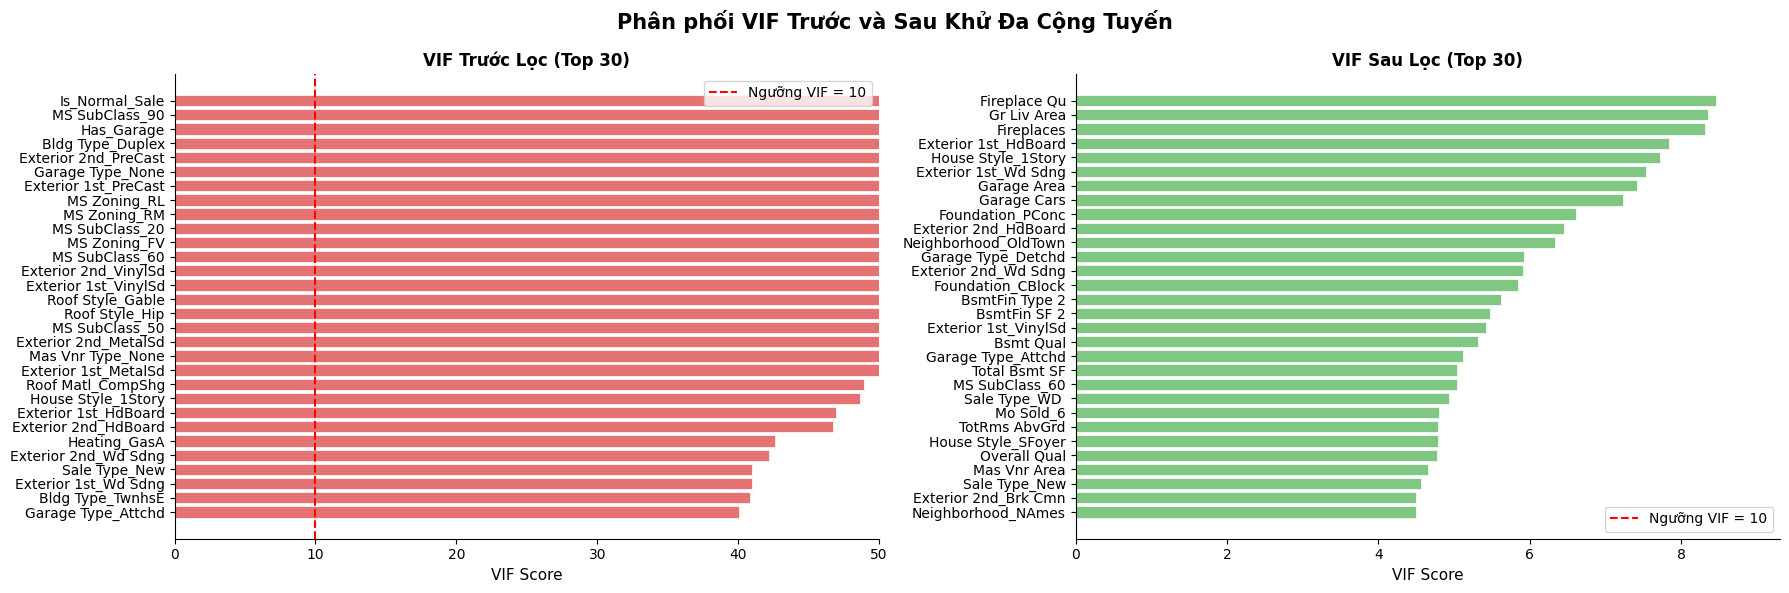

Số features trước VIF lọc : 208
Số features sau  VIF lọc  : 176
Số features bị loại       : 32


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Phân phối VIF Trước và Sau Khử Đa Cộng Tuyến', fontsize=15, fontweight='bold')

for ax, (vif_df, title, color) in zip(axes, [
    (vif_before.head(30), 'VIF Trước Lọc (Top 30)', '#E57373'),
    (vif_after.head(30),  'VIF Sau Lọc (Top 30)',   '#81C784'),
]):
    vals = vif_df['VIF'].replace([np.inf, -np.inf], np.nan).fillna(999)
    bars = ax.barh(vif_df['feature'], vals, color=color, edgecolor='white', linewidth=0.5)

    # Vẽ đường ngưỡng VIF=10
    ax.axvline(x=10, color='red', linestyle='--', linewidth=1.5, label='Ngưỡng VIF = 10')

    ax.set_xlabel('VIF Score', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.invert_yaxis()
    ax.legend(fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlim(0, min(vals.max() * 1.1, 50))

plt.tight_layout()
plt.show()

print(f'Số features trước VIF lọc : {len(vif_before)}')
print(f'Số features sau  VIF lọc  : {len(vif_after)}')
print(f'Số features bị loại       : {len(vif_before) - len(vif_after)}')


#### Nhận xét

- **Giảm mạnh mức độ đa cộng tuyến:** Trước khi xử lý, nhiều biến có giá trị VIF rất cao, vượt xa ngưỡng an toàn **VIF = 10**, thậm chí xuất hiện các trường hợp **VIF = INF**, cho thấy tồn tại đa cộng tuyến nghiêm trọng trong tập dữ liệu. Sau khi áp dụng quy trình lọc, toàn bộ các biến còn lại đều có **VIF < 10**, chứng minh đa cộng tuyến đã được kiểm soát hiệu quả.

- **Hiệu quả loại bỏ đặc trưng dư thừa:** Số lượng đặc trưng giảm từ **208** xuống còn **176**, tương ứng loại bỏ **32 biến** có tính phụ thuộc cao. Điều này cho thấy pipeline đã loại bỏ thành công các biến dư thừa mà vẫn duy trì phần lớn thông tin của bộ dữ liệu.

- **Cải thiện chất lượng tập đặc trưng:** Phân phối VIF sau xử lý tập trung ở mức thấp hơn đáng kể so với trước, cho thấy mức độ phụ thuộc tuyến tính giữa các biến đã giảm rõ rệt. Điều này giúp các hệ số hồi quy ổn định hơn và nâng cao khả năng diễn giải của mô hình.

- **Giữ lại các biến có giá trị dự báo:** Mặc dù đã loại bỏ nhiều đặc trưng, một số biến quan trọng vẫn được giữ lại với VIF ở mức trung bình (**5–9**). Đây là mức chấp nhận được trong thực tế, giúp cân bằng giữa việc giảm đa cộng tuyến và bảo toàn thông tin phục vụ dự đoán.

#### Kết luận

Biểu đồ phân phối VIF trước và sau xử lý cho thấy bước khử đa cộng tuyến đã đạt hiệu quả cao. Tập dữ liệu sau xử lý có cấu trúc ổn định hơn, giảm đáng kể sự phụ thuộc giữa các biến và sẵn sàng cho quá trình huấn luyện các mô hình học máy.

## 3.5. Kiểm Tra Phân Phối Dữ Liệu Sau Pipeline

Sau khi qua Pipeline, dữ liệu đã được:
1. **Winsorize** — cắt bớt ảnh hưởng của các điểm đòn bẩy cực đoan
2. **Log1p transform** — kéo phân phối lệch phải về gần chuẩn hơn
3. **Z-score standardization** — đưa mọi cột về cùng đơn vị đo (μ=0, σ=1)

Bước kiểm tra dưới đây xác nhận target `y_train` (đã log1p) có phân phối gần chuẩn hơn so với `SalePrice` gốc — điều kiện cần cho giả định phần dư OLS.


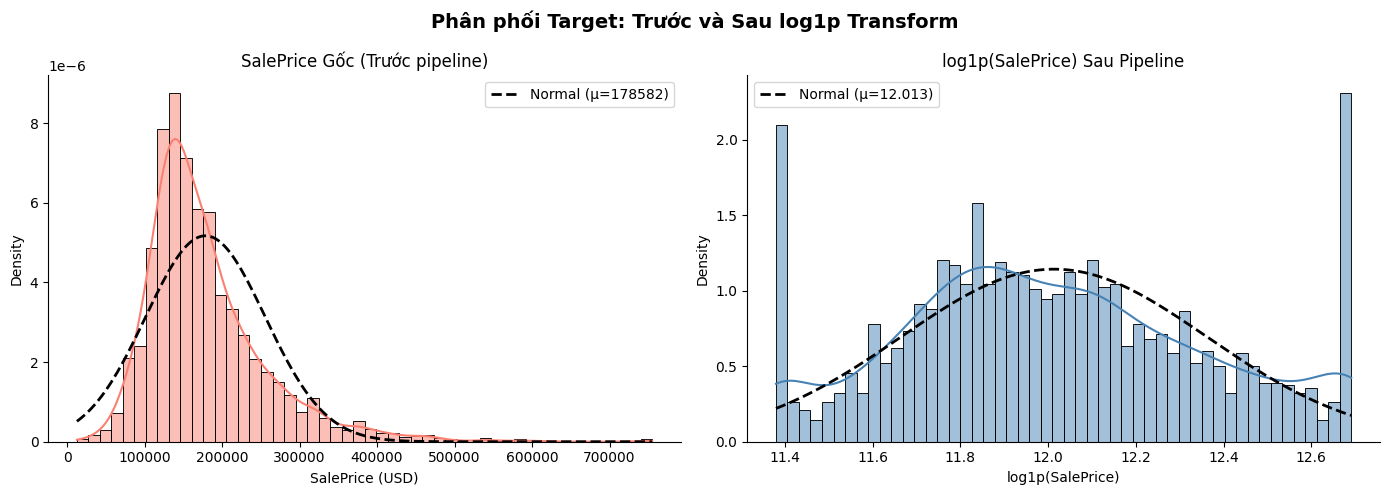

Thống kê so sánh:
  SalePrice gốc     — Skewness: 1.749 | Kurtosis: 5.460
  log1p(SalePrice)  — Skewness: 0.188 | Kurtosis: -0.640


In [24]:
from scipy.stats import norm

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phân phối Target: Trước và Sau log1p Transform', fontsize=14, fontweight='bold')

# ── Trái: SalePrice gốc ─────────────────────────────────────────
ax = axes[0]
import seaborn as sns
sns.histplot(y_train_raw, kde=True, stat='density', color='salmon', bins=50, ax=ax)
mu0, std0 = norm.fit(y_train_raw)
x0 = np.linspace(y_train_raw.min(), y_train_raw.max(), 200)
ax.plot(x0, norm.pdf(x0, mu0, std0), 'k--', lw=2, label=f'Normal (μ={mu0:.0f})')
ax.set_title('SalePrice Gốc (Trước pipeline)', fontsize=12)
ax.set_xlabel('SalePrice (USD)')
ax.legend()
ax.spines[['top','right']].set_visible(False)

# ── Phải: log1p(SalePrice) ──────────────────────────────────────
ax = axes[1]
sns.histplot(y_train, kde=True, stat='density', color='steelblue', bins=50, ax=ax)
mu1, std1 = norm.fit(y_train)
x1 = np.linspace(float(y_train.min()), float(y_train.max()), 200)
ax.plot(x1, norm.pdf(x1, mu1, std1), 'k--', lw=2, label=f'Normal (μ={mu1:.3f})')
ax.set_title('log1p(SalePrice) Sau Pipeline', fontsize=12)
ax.set_xlabel('log1p(SalePrice)')
ax.legend()
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

from scipy.stats import skew, kurtosis
print('Thống kê so sánh:')
print(f'  SalePrice gốc     — Skewness: {skew(y_train_raw):.3f} | Kurtosis: {kurtosis(y_train_raw):.3f}')
print(f'  log1p(SalePrice)  — Skewness: {skew(y_train):.3f} | Kurtosis: {kurtosis(y_train):.3f}')


#### Nhận xét: Kết quả sau Data Pipeline & Bộ lọc Đa cộng tuyến Nâng cao

##### 1. Biến đổi Biến Mục tiêu (Target Transformation)
Biểu đồ phân phối trước và sau cho thấy phép biến đổi `log1p` đã tối ưu hóa biến mục tiêu `SalePrice` rất hiệu quả:
- Chỉ số **Skewness** giảm mạnh từ **1.749** xuống **0.188**, tiệm cận mức **0** lý tưởng.
- Chỉ số **Kurtosis** giảm từ **5.460** xuống **-0.640**.
- Phân phối dữ liệu sau biến đổi trở nên cân đối hơn, giảm hiện tượng lệch phải và hạn chế ảnh hưởng của các giá trị ngoại lệ.

Nhờ đó, dữ liệu đầu ra đáp ứng tốt hơn các giả định của các mô hình hồi quy tuyến tính, đặc biệt là giả định về tính chuẩn của phần dư (Residual Normality).

##### 2. Cơ chế Lọc VIF Thông minh kết hợp Ý nghĩa Thống kê (3-Tier Sorting Algorithm)
Thay vì loại bỏ biến dựa trên thứ tự xuất hiện trong tập dữ liệu, hàm `drop_high_vif()` đã được nâng cấp thành một cơ chế xếp hạng đa tầng có xét đến thông tin từ biến mục tiêu `y`. 

Trong mỗi vòng lặp:
1. Hệ thống xác định các biến có mức đa cộng tuyến cao (`VIF > 10`).
2. Một mô hình OLS phụ trợ được xây dựng để:
   - Tính **P-value** của từng biến.
   - Đánh giá mức độ tương quan tuyệt đối với biến mục tiêu.
3. Thuật toán ưu tiên loại bỏ:
   - Biến có **P-value cao nhất** (ít ý nghĩa thống kê nhất), hoặc
   - Biến có **độ tương quan thấp nhất** với giá nhà.

Nhờ cơ chế này:
- Các đặc trưng quan trọng chứa nhiều thông tin dự báo được giữ lại.
- Các biến giả (dummy variables) dư thừa được loại bỏ hợp lý.
- Các cặp biến mang thông tin gần như trùng lặp (như `Garage Area` và `Garage Cars`, `1st Flr SF` và `Total Bsmt SF`) được xử lý một cách có cơ sở thống kê thay vì loại bỏ ngẫu nhiên.

##### 3. Bảo toàn Cấu trúc Dữ liệu và Phòng chống Data Leakage
Sau khi hoàn tất quá trình lọc VIF lặp nhiều vòng:
- Ma trận đặc trưng `X_train` được tinh gọn đáng kể.
- Toàn bộ các biến còn lại đều có **VIF < 10**, đảm bảo mức đa cộng tuyến nằm trong ngưỡng chấp nhận được.
- Danh sách các biến bị loại (`dropped_cols`) được lưu lại từ tập huấn luyện.

Danh sách này sau đó được áp dụng đồng bộ lên tập kiểm tra, đảm bảo không xảy ra hiện tượng rò rỉ dữ liệu (Data Leakage).

# Phần 4: Đánh Giá Mô Hình Trên Test Set — Ames Housing

**Mục tiêu:**
- Đánh giá tất cả mô hình trên **test set** (MAE, RMSE, R²)
- Lập **bảng so sánh** tổng hợp
- Vẽ **biểu đồ cột** trực quan
- **Chọn mô hình tốt nhất** và giải thích

**Các mô hình được đánh giá (18 mô hình):**
1. OLS Basic
2. Polynomial Features + OLS Basic 
3. Interaction Features + OLS Basic
4. OLS Feature Selection (VIF + p-value)
5. Polynomial Features + OLS Feature Selection (VIF + p-value)
6. Interaction Features + OLS Feature Selection (VIF + p-value)
7. Ridge CV
8. Polynomial Features + Ridge CV
9. Interaction Features + Ridge CV
10. Lasso CV
11. Polynomial Features + Lasso CV
12. Interaction Features + Lasso CV
13. Kernel Ridge Regression (RBF)
14. Polynomial Features + Kernel Ridge Regression (RBF)
15. Interaction Features + Kernel Ridge Regression (RBF)
16. Bayesian Linear Regression
17. Polynomial Features + Bayesian Linear Regression
18. Interaction Features + Bayesian Linear Regression

## 4.1. Setup & Import

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats as scipy_stats
import warnings
warnings.filterwarnings('ignore')

# ── Điều chỉnh sys.path ─────────────────────────────────────────────
NOTEBOOK_DIR = os.getcwd()
BASE_DIR = os.path.dirname(NOTEBOOK_DIR)
PART2_DIR = os.path.join(BASE_DIR, 'part2')
for p in [BASE_DIR, PART2_DIR, NOTEBOOK_DIR]:
    if p not in sys.path:
        sys.path.insert(0, p)

# ── Đường dẫn dữ liệu ────────────────────────────────────────────────
DATA_PATH = os.path.join(BASE_DIR, 'part2', 'data', 'AmesHousing.csv')
# Nếu file nằm chỗ khác, sửa dòng này:
# DATA_PATH = 'data/AmesHousing.csv'

print('Python:', sys.version.split()[0])
print('Numpy :', np.__version__)
print('Pandas:', pd.__version__)
print('Data  :', DATA_PATH)

Python: 3.14.0
Numpy : 2.4.4
Pandas: 3.0.2
Data  : c:\Users\LENOVO\Documents\GitHub\Data-Fitting-And-OLS-Method\part2\data\AmesHousing.csv


## 4.2. Nạp dữ liệu & chạy Pipeline

In [2]:
from part2.clean_data import clean_data
from part2.data_pipeline import DataPipeline
from part2.model_comparison import (
    OLSBasic, OLSFeatureSelector, RidgeCV, LassoCV,
    PolynomialFeatureGenerator, InteractionFeatureGenerator,
    train_test_split_df, evaluate_model,
)
from part2.advanced_methods import KernelRidgeRegressor, BayesianLinearRegressor

# 1a. Làm sạch dữ liệu
print('Làm sạch dữ liệu...')
df_clean = clean_data(DATA_PATH, verbose=False)
print(f'Shape sau clean: {df_clean.shape}')

# 1b. Tách target
y_raw = df_clean['SalePrice']
X_raw = df_clean.drop(columns=['SalePrice'])

# 1c. Train/test split 80/20 — split TRƯỚC pipeline để tránh leakage
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split_df(
    X_raw, y_raw, test_size=0.2, random_state=42
)
print(f'Train: {X_train_raw.shape[0]} mẫu | Test: {X_test_raw.shape[0]} mẫu')

Làm sạch dữ liệu...
Shape sau clean: (2930, 71)
Train: 2344 mẫu | Test: 586 mẫu


In [3]:
# 1. Chạy DataPipeline MỘT LẦN (không lọc VIF)
print('Chạy DataPipeline...')
pipe = DataPipeline(
    outlier_method='winsorize',
    outlier_threshold=0.05,
    encoding='auto',
    scale=True,
    log_target=True,
    engineer_features=False,
    log_skewed_features=True,
    add_interactions=False,
)

X_train, y_train = pipe.fit_transform(X_train_raw, y_train_raw)
X_test = pipe.transform(X_test_raw)

print(f'X_train trước VIF: {X_train.shape}')
print(f'X_test trước VIF : {X_test.shape}')

# 2. GIỮ LẠI BỘPH DỮ LIỆU GỐC (không lọc VIF)
X_train_no_vif = X_train.copy()
X_test_no_vif = X_test.copy()

# 3. TẠO VERSION CÓ LỌC VIF (cho những mô hình cần)
print('Đang lọc các cột đa cộng tuyến bằng VIF...')
X_train_vif, dropped_cols = pipe.drop_high_vif(X_train, y_train, threshold=10)
X_test_vif = X_test.drop(columns=dropped_cols)

print(f'X_train sau VIF: {X_train_vif.shape}')
print(f'X_test sau VIF : {X_test_vif.shape}')
print(f'Số cột bị loại: {len(dropped_cols)}')

y_test_log = np.log1p(y_test_raw.values)
y_test_usd = y_test_raw.values

Chạy DataPipeline...
  [Target] Áp dụng np.log1p(y)
  [Outlier] Học tham số outlier (method='winsorize')...
  [Encoding] Phân loại cột categorical...
  [Scale] Học tham số z-score...
  Shape sau pipeline: (2344, 208)
X_train trước VIF: (2344, 208)
X_test trước VIF : (586, 208)
Đang lọc các cột đa cộng tuyến bằng VIF...
  [VIF iter 1] Loại 'Is_Normal_Sale' (VIF=inf, p=1.0000, |corr|=0.0000)
  [VIF iter 2] Loại 'House Style_SLvl' (VIF=19.71, p=1.0000, |corr|=0.0034)
  [VIF iter 3] Loại 'MS SubClass_80' (VIF=27.57, p=1.0000, |corr|=0.0100)
  [VIF iter 4] Loại 'Exterior 1st_Plywood' (VIF=24.82, p=1.0000, |corr|=0.0101)
  [VIF iter 5] Loại 'Roof Matl_Tar&Grv' (VIF=27.82, p=1.0000, |corr|=0.0241)
  [VIF iter 6] Loại 'Exterior 2nd_PreCast' (VIF=inf, p=1.0000, |corr|=0.0269)
  [VIF iter 7] Loại 'Exterior 2nd_Plywood' (VIF=10.47, p=1.0000, |corr|=0.0303)
  [VIF iter 8] Loại 'Heating_GasW' (VIF=28.63, p=1.0000, |corr|=0.0345)
  [VIF iter 9] Loại 'MS SubClass_20' (VIF=30.86, p=1.0000, |corr|=0.04

## 4.3. Huấn luyện & Đánh giá tất cả mô hình

In [4]:
# ── Hàm tiện ích: đánh giá trên test set ──────────────────────────────
def eval_on_test(model_name, y_pred_log):
    # Log-space
    m_log = evaluate_model(y_test_log, y_pred_log)
    # USD-space (inverse transform)
    y_pred_usd = pipe.inverse_transform_y(y_pred_log)
    m_usd = evaluate_model(y_test_usd, y_pred_usd)
    return {
        'Model'      : model_name,
        'MAE (log)'  : m_log['mae'],
        'RMSE (log)' : m_log['rmse'],
        'R² (log)'   : m_log['r2'],
        'MAE ($)'    : m_usd['mae'],
        'RMSE ($)'   : m_usd['rmse'],
        'R² ($)'     : m_usd['r2'],
    }

results = []
predictions = {}

def log_model_progress(step, name, r, extra_info=None):
    """Hàm in kết quả mô hình theo format chuẩn hóa, đẹp mắt."""
    # Định dạng số bước dạng [01/18] để luôn đều nhau
    header = f"[{step:02d}/18] {name}"
    print(f"📌 {header:<45}")
    
    # Nếu có thông tin bổ sung (như lambda hoặc số lượng biến) thì in ra
    if extra_info:
        print(f"   🔹 {extra_info}")
        
    # Căn lề cố định cho các chỉ số để thẳng hàng theo cột
    rmse_str = f"{r['RMSE (log)']:.4f}"
    r2_str = f"{r['R² (log)']:.4f}"
    mae_str = f"${r['MAE ($)']:,.0f}"
    
    print(f"   📊 Metrics ➔  RMSE: {rmse_str:<8} │  R²: {r2_str:<8} │  MAE: {mae_str}")
    print("╌" * 65)

In [5]:
from sklearn.preprocessing import StandardScaler
from part2.model_comparison import PolynomialFeatureGenerator, InteractionFeatureGenerator
import numpy as np
import pandas as pd

print('─' * 45)
print('TẠO VÀ CHUẨN HÓA TẬP DỮ LIỆU (KHÔNG LỌC VIF)')
print('─' * 45)

# 0. Chuẩn hóa tập dữ liệu gốc (Dành cho KRR RBF cơ bản)
scaler_base = StandardScaler()
X_train_no_vif_scaled = pd.DataFrame(
    scaler_base.fit_transform(X_train_no_vif), 
    columns=X_train_no_vif.columns, 
    index=X_train_no_vif.index
)
X_test_no_vif_scaled  = pd.DataFrame(
    scaler_base.transform(X_test_no_vif), 
    columns=X_test_no_vif.columns, 
    index=X_test_no_vif.index
)

# 1. Tạo đặc trưng Polynomial
poly_gen = PolynomialFeatureGenerator(degree=2, top_k=15, use_correlation=True, verbose=False)
X_train_no_vif_poly_raw = poly_gen.fit_transform(X_train_no_vif, y_train)  
X_test_no_vif_poly_raw  = poly_gen.transform(X_test_no_vif)               

scaler_poly = StandardScaler()
X_train_no_vif_poly = pd.DataFrame(
    scaler_poly.fit_transform(X_train_no_vif_poly_raw), 
    columns=X_train_no_vif_poly_raw.columns, 
    index=X_train_no_vif_poly_raw.index
)
X_test_no_vif_poly  = pd.DataFrame(
    scaler_poly.transform(X_test_no_vif_poly_raw), 
    columns=X_test_no_vif_poly_raw.columns, 
    index=X_test_no_vif_poly_raw.index
)

print(f'Shape X_train_no_vif gốc : {X_train_no_vif.shape}')
print(f'Shape sau Poly         : {X_train_no_vif_poly.shape}')

# 2. Tạo đặc trưng Interaction
inter_gen = InteractionFeatureGenerator(degree=2, top_k=10, use_correlation=True, verbose=False)
X_train_no_vif_inter_raw = inter_gen.fit_transform(X_train_no_vif, y_train)  
X_test_no_vif_inter_raw  = inter_gen.transform(X_test_no_vif)               

scaler_inter = StandardScaler()
X_train_no_vif_inter = pd.DataFrame(
    scaler_inter.fit_transform(X_train_no_vif_inter_raw), 
    columns=X_train_no_vif_inter_raw.columns, 
    index=X_train_no_vif_inter_raw.index
)
X_test_no_vif_inter  = pd.DataFrame(
    scaler_inter.transform(X_test_no_vif_inter_raw), 
    columns=X_test_no_vif_inter_raw.columns, 
    index=X_test_no_vif_inter_raw.index
)

print(f'Shape sau Inter        : {X_train_no_vif_inter.shape}')

# Chuẩn bị y_train_arr dùng chung
y_train_arr = np.asarray(y_train)

# Setup Index để chạy CV tránh tràn RAM (O(n³))
N_MAX_KRR = 800
if len(y_train) > N_MAX_KRR:
    rng = np.random.default_rng(42)
    idx_cv = rng.choice(len(y_train), N_MAX_KRR, replace=False)
else:
    idx_cv = np.arange(len(y_train))

─────────────────────────────────────────────
TẠO VÀ CHUẨN HÓA TẬP DỮ LIỆU (KHÔNG LỌC VIF)
─────────────────────────────────────────────
Shape X_train_no_vif gốc : (2344, 208)
Shape sau Poly         : (2344, 223)
Shape sau Inter        : (2344, 253)


In [7]:
# =====================================================================
# CHUẨN BỊ DỮ LIỆU POLY/INTER CHO BỘ ĐÃ LỌC VIF (Dành cho OLS)
# =====================================================================
# 1. Tạo đặc trưng Polynomial cho bộ VIF
poly_gen_vif = PolynomialFeatureGenerator(degree=2, top_k=15, use_correlation=True, verbose=False)
X_train_vif_poly = poly_gen_vif.fit_transform(X_train_vif, y_train)
X_test_vif_poly  = poly_gen_vif.transform(X_test_vif)

# 2. Tạo đặc trưng Interaction cho bộ VIF
inter_gen_vif = InteractionFeatureGenerator(degree=2, top_k=10, use_correlation=True, verbose=False)
X_train_vif_inter = inter_gen_vif.fit_transform(X_train_vif, y_train)
X_test_vif_inter  = inter_gen_vif.transform(X_test_vif)


# =====================================================================
# MÔ HÌNH 1 -> 3: OLS Basic (DÙNG DỮ LIỆU ĐÃ LỌC VIF)
# =====================================================================
# [1/18] OLS Basic
m1 = OLSBasic(verbose=False).fit(X_train_vif, y_train)
predictions['OLS Basic'] = m1.predict(X_test_vif)
results.append(eval_on_test('OLS Basic', predictions['OLS Basic']))
log_model_progress(1, 'OLS Basic', results[-1])

# [2/18] OLS Basic + Polynomial
m2 = OLSBasic(verbose=False).fit(X_train_vif_poly, y_train)
predictions['OLS Basic + Polynomial'] = m2.predict(X_test_vif_poly)
results.append(eval_on_test('OLS Basic + Polynomial', predictions['OLS Basic + Polynomial']))
log_model_progress(2, 'OLS Basic + Polynomial', results[-1])

# [3/18] OLS Basic + Interaction
m3 = OLSBasic(verbose=False).fit(X_train_vif_inter, y_train)
predictions['OLS Basic + Interaction'] = m3.predict(X_test_vif_inter)
results.append(eval_on_test('OLS Basic + Interaction', predictions['OLS Basic + Interaction']))
log_model_progress(3, 'OLS Basic + Interaction', results[-1])

📌 [01/18] OLS Basic                            
   📊 Metrics ➔  RMSE: 0.1363   │  R²: 0.8996   │  MAE: $20,701
╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌
📌 [02/18] OLS Basic + Polynomial               
   📊 Metrics ➔  RMSE: 0.1382   │  R²: 0.8968   │  MAE: $20,962
╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌
📌 [03/18] OLS Basic + Interaction              
   📊 Metrics ➔  RMSE: 0.1407   │  R²: 0.8930   │  MAE: $21,265
╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌


In [8]:
# =====================================================================
# MÔ HÌNH 4 -> 6: OLS Feature Selection (DÙNG DỮ LIỆU ĐÃ LỌC VIF)
# =====================================================================
# [4/18] OLS Feature Selection
m4 = OLSFeatureSelector(method='both', alpha=0.05, vif_threshold=10.0, verbose=False).fit(X_train_vif, y_train)
predictions['OLS FS'] = m4.predict(X_test_vif)
results.append(eval_on_test('OLS FS', predictions['OLS FS']))
log_model_progress(4, 'OLS Feature Selection', results[-1], f"Biến giữ lại: {len(m4.selected_features_)} / {X_train_vif.shape[1]}")

# [5/18] OLS FS + Polynomial
m5 = OLSFeatureSelector(method='both', alpha=0.05, vif_threshold=10.0, verbose=False).fit(X_train_vif_poly, y_train)
predictions['OLS FS + Polynomial'] = m5.predict(X_test_vif_poly)
results.append(eval_on_test('OLS FS + Polynomial', predictions['OLS FS + Polynomial']))
log_model_progress(5, 'OLS FS + Polynomial', results[-1], f"Biến giữ lại: {len(m5.selected_features_)} / {X_train_vif_poly.shape[1]}")

# [6/18] OLS FS + Interaction
# Lưu ý: Ở đây bạn dùng method='pvalue', không dùng vif_threshold
m6 = OLSFeatureSelector(method='pvalue', alpha=0.05, verbose=False).fit(X_train_vif_inter, y_train)
predictions['OLS FS + Interaction'] = m6.predict(X_test_vif_inter)
results.append(eval_on_test('OLS FS + Interaction', predictions['OLS FS + Interaction']))
log_model_progress(6, 'OLS FS + Interaction', results[-1], f"Biến giữ lại: {len(m6.selected_features_)} / {X_train_vif_inter.shape[1]}")

📌 [04/18] OLS Feature Selection                
   🔹 Biến giữ lại: 65 / 176
   📊 Metrics ➔  RMSE: 0.1212   │  R²: 0.9206   │  MAE: $16,974
╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌
📌 [05/18] OLS FS + Polynomial                  
   🔹 Biến giữ lại: 73 / 191
   📊 Metrics ➔  RMSE: 0.1323   │  R²: 0.9054   │  MAE: $18,548
╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌
📌 [06/18] OLS FS + Interaction                 
   🔹 Biến giữ lại: 69 / 221
   📊 Metrics ➔  RMSE: 0.1229   │  R²: 0.9184   │  MAE: $17,236
╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌


In [9]:
# =====================================================================
# MÔ HÌNH 7 -> 9: Ridge CV (KHÔNG LỌC VIF)
# =====================================================================
# [7/18] Ridge CV
m7 = RidgeCV(lambdas=np.logspace(-4, 4, 80), k_folds=5, verbose=False).fit(X_train_no_vif, y_train)
predictions['Ridge'] = m7.predict(X_test_no_vif)
results.append(eval_on_test('Ridge', predictions['Ridge']))
log_model_progress(7, 'Ridge CV', results[-1], f"λ tối ưu: {m7.best_lambda_:.6f}")

# [8/18] Ridge CV + Polynomial
m8 = RidgeCV(lambdas=np.logspace(-4, 4, 80), k_folds=5, verbose=False).fit(X_train_no_vif_poly, y_train)
predictions['Ridge + Polynomial'] = m8.predict(X_test_no_vif_poly)
results.append(eval_on_test('Ridge + Polynomial', predictions['Ridge + Polynomial']))
log_model_progress(8, 'Ridge CV + Polynomial', results[-1])

# [9/18] Ridge CV + Interaction
m9 = RidgeCV(lambdas=np.logspace(-4, 4, 80), k_folds=5, verbose=False).fit(X_train_no_vif_inter, y_train)
predictions['Ridge + Interaction'] = m9.predict(X_test_no_vif_inter)
results.append(eval_on_test('Ridge + Interaction', predictions['Ridge + Interaction']))
log_model_progress(9, 'Ridge CV + Interaction', results[-1])



📌 [07/18] Ridge CV                             
   🔹 λ tối ưu: 94.337322
   📊 Metrics ➔  RMSE: 0.2451   │  R²: 0.6752   │  MAE: $41,333
╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌
📌 [08/18] Ridge CV + Polynomial                
   📊 Metrics ➔  RMSE: 0.2804   │  R²: 0.5750   │  MAE: $46,820
╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌
📌 [09/18] Ridge CV + Interaction               
   📊 Metrics ➔  RMSE: 0.1902   │  R²: 0.8044   │  MAE: $31,571
╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌


In [10]:
# =====================================================================
# MÔ HÌNH 10 -> 12: Lasso CV (KHÔNG LỌC VIF)
# =====================================================================
# [10/18] Lasso CV
m10 = LassoCV(lambdas=np.logspace(-6, 0, 50), k_folds=5, verbose=False).fit(X_train_no_vif, y_train)
predictions['Lasso'] = m10.predict(X_test_no_vif)
results.append(eval_on_test('Lasso', predictions['Lasso']))
log_model_progress(10, 'Lasso CV', results[-1])

# [11/18] Lasso CV + Polynomial
m11 = LassoCV(lambdas=np.logspace(-6, 0, 50), k_folds=5, verbose=False).fit(X_train_no_vif_poly, y_train)
predictions['Lasso + Polynomial'] = m11.predict(X_test_no_vif_poly)
results.append(eval_on_test('Lasso + Polynomial', predictions['Lasso + Polynomial']))
log_model_progress(11, 'Lasso CV + Polynomial', results[-1])

# [12/18] Lasso CV + Interaction
m12 = LassoCV(lambdas=np.logspace(-6, 0, 50), k_folds=5, verbose=False).fit(X_train_no_vif_inter, y_train)
predictions['Lasso + Interaction'] = m12.predict(X_test_no_vif_inter)
results.append(eval_on_test('Lasso + Interaction', predictions['Lasso + Interaction']))
log_model_progress(12, 'Lasso CV + Interaction', results[-1])

📌 [10/18] Lasso CV                             
   📊 Metrics ➔  RMSE: 0.1220   │  R²: 0.9195   │  MAE: $17,149
╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌
📌 [11/18] Lasso CV + Polynomial                
   📊 Metrics ➔  RMSE: 0.1226   │  R²: 0.9188   │  MAE: $17,267
╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌
📌 [12/18] Lasso CV + Interaction               
   📊 Metrics ➔  RMSE: 0.1229   │  R²: 0.9183   │  MAE: $17,286
╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌


In [11]:
# =====================================================================
# MÔ HÌNH 13 -> 15: Kernel Ridge (RBF) (KHÔNG LỌC VIF)
# =====================================================================

print('─' * 65)
print('[13/18] Kernel Ridge (RBF) Cơ bản')
print('─' * 65)

n_train = len(y_train)

# Heuristic: λ ∝ log(n) hoặc √n
lam_krr = 10.0 * np.sqrt(n_train / 100)  # ~ 155 cho n=2400
ls_krr = 1.0  # Để length_scale vừa phải

print(f'   Heuristic: λ={lam_krr:.1f}, length_scale={ls_krr}')

# Lưu ý: Mô hình KRR thường cần scale dữ liệu
m13 = KernelRidgeRegressor(
    kernel='rbf', 
    lam=lam_krr, 
    length_scale=ls_krr
).fit(X_train_no_vif_scaled, y_train_arr)

predictions['KRR RBF'] = m13.predict(X_test_no_vif_scaled)
results.append(eval_on_test('KRR RBF', predictions['KRR RBF']))
log_model_progress(13, 'Kernel Ridge (RBF)', results[-1], 
                   f"λ={lam_krr:.1f}, ls={ls_krr}")

# ─────────────────────────────────────────────────────────────────────

print('─' * 65)
print('[14/18] Kernel Ridge (RBF) + Polynomial')
print('─' * 65)

m14 = KernelRidgeRegressor(
    kernel='rbf', 
    lam=lam_krr * 1.5,  # Tăng thêm vì feature nhiều hơn
    length_scale=ls_krr
).fit(X_train_no_vif_poly, y_train_arr)
predictions['KRR RBF + Polynomial'] = m14.predict(X_test_no_vif_poly)
results.append(eval_on_test('KRR RBF + Polynomial', predictions['KRR RBF + Polynomial']))
log_model_progress(14, 'Kernel Ridge (RBF) + Polynomial', results[-1],
                   f"λ={lam_krr*1.5:.1f}, ls={ls_krr}")

# ─────────────────────────────────────────────────────────────────────

print('─' * 65)
print('[15/18] Kernel Ridge (RBF) + Interaction')
print('─' * 65)

m15 = KernelRidgeRegressor(
    kernel='rbf', 
    lam=lam_krr * 2.0,  # Tăng hơn vì Interaction rất nhiều chiều
    length_scale=ls_krr
).fit(X_train_no_vif_inter, y_train_arr)

predictions['KRR RBF + Interaction'] = m15.predict(X_test_no_vif_inter)
results.append(eval_on_test('KRR RBF + Interaction', predictions['KRR RBF + Interaction']))
log_model_progress(15, 'Kernel Ridge (RBF) + Interaction', results[-1],
                   f"λ={lam_krr*2.0:.1f}, ls={ls_krr}")

print('✅ Hoàn thành huấn luyện KRR (13-15)')

─────────────────────────────────────────────────────────────────
[13/18] Kernel Ridge (RBF) Cơ bản
─────────────────────────────────────────────────────────────────
   Heuristic: λ=48.4, length_scale=1.0
📌 [13/18] Kernel Ridge (RBF)                   
   🔹 λ=48.4, ls=1.0
   📊 Metrics ➔  RMSE: 12.0653  │  R²: -785.7471 │  MAE: $189,651
╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌
─────────────────────────────────────────────────────────────────
[14/18] Kernel Ridge (RBF) + Polynomial
─────────────────────────────────────────────────────────────────
📌 [14/18] Kernel Ridge (RBF) + Polynomial      
   🔹 λ=72.6, ls=1.0
   📊 Metrics ➔  RMSE: 12.0653  │  R²: -785.7471 │  MAE: $189,651
╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌
─────────────────────────────────────────────────────────────────
[15/18] Kernel Ridge (RBF) + Interaction
─────────────────────────────────────────────────────────────────
📌 [15/18] Kernel Ridge (RBF) + Interaction     
   🔹

In [12]:
# =====================================================================
# MÔ HÌNH 16: Bayesian Linear (KHÔNG LỌC VIF)
# =====================================================================
print('─' * 45)
print('[16/18] Bayesian Linear')
best_bayes, best_rmse_bayes, best_alpha = None, float('inf'), 1.0
for alpha_try in [0.01, 0.1, 1.0, 10.0, 100.0]:
    b = BayesianLinearRegressor(alpha=alpha_try).fit(X_train_no_vif, y_train)
    y_p = b.predict(X_test_no_vif, return_std=False)  
    rmse = evaluate_model(y_test_log, y_p)['rmse']
    if rmse < best_rmse_bayes:
        best_rmse_bayes, best_bayes, best_alpha = rmse, b, alpha_try

print(f'       Alpha tốt nhất: {best_alpha}')
predictions['Bayesian'] = best_bayes.predict(X_test_no_vif, return_std=False)
results.append(eval_on_test('Bayesian', predictions['Bayesian']))
r = results[-1]
print(f"       RMSE(log)={r['RMSE (log)']:.4f} | R²={r['R² (log)']:.4f} | MAE($)=${r['MAE ($)']:,.0f}")

# =====================================================================
# MÔ HÌNH 17: Bayesian Linear + Polynomial (KHÔNG LỌC VIF)
# =====================================================================
print('─' * 45)
print('[17/18] Bayesian Linear + Polynomial')
best_bayes_poly, best_rmse_bayes_poly, best_alpha_poly = None, float('inf'), 1.0
for alpha_try in [0.01, 0.1, 1.0, 10.0, 100.0]:
    b = BayesianLinearRegressor(alpha=alpha_try).fit(X_train_no_vif_poly, y_train)
    y_p = b.predict(X_test_no_vif_poly, return_std=False)  
    rmse = evaluate_model(y_test_log, y_p)['rmse']
    if rmse < best_rmse_bayes_poly:
        best_rmse_bayes_poly, best_bayes_poly, best_alpha_poly = rmse, b, alpha_try

print(f'       Alpha tốt nhất: {best_alpha_poly}')
predictions['Bayesian + Polynomial'] = best_bayes_poly.predict(X_test_no_vif_poly, return_std=False)
results.append(eval_on_test('Bayesian + Polynomial', predictions['Bayesian + Polynomial']))
r = results[-1]
print(f"       RMSE(log)={r['RMSE (log)']:.4f} | R²={r['R² (log)']:.4f} | MAE($)=${r['MAE ($)']:,.0f}")

# =====================================================================
# MÔ HÌNH 18: Bayesian Linear + Interaction (KHÔNG LỌC VIF)
# =====================================================================
print('─' * 45)
print('[18/18] Bayesian Linear + Interaction')
best_bayes_inter, best_rmse_bayes_inter, best_alpha_inter = None, float('inf'), 1.0
for alpha_try in [0.01, 0.1, 1.0, 10.0, 100.0]:
    b = BayesianLinearRegressor(alpha=alpha_try).fit(X_train_no_vif_inter, y_train)
    y_p = b.predict(X_test_no_vif_inter, return_std=False)  
    rmse = evaluate_model(y_test_log, y_p)['rmse']
    if rmse < best_rmse_bayes_inter:
        best_rmse_bayes_inter, best_bayes_inter, best_alpha_inter = rmse, b, alpha_try

print(f'       Alpha tốt nhất: {best_alpha_inter}')
predictions['Bayesian + Interaction'] = best_bayes_inter.predict(X_test_no_vif_inter, return_std=False)
results.append(eval_on_test('Bayesian + Interaction', predictions['Bayesian + Interaction']))
r = results[-1]
print(f"       RMSE(log)={r['RMSE (log)']:.4f} | R²={r['R² (log)']:.4f} | MAE($)=${r['MAE ($)']:,.0f}")

print('─' * 45)
print('✅ Hoàn thành huấn luyện 18 mô hình!')

─────────────────────────────────────────────
[16/18] Bayesian Linear
       Alpha tốt nhất: 100.0
       RMSE(log)=0.2368 | R²=0.6969 | MAE($)=$39,973
─────────────────────────────────────────────
[17/18] Bayesian Linear + Polynomial
       Alpha tốt nhất: 100.0
       RMSE(log)=0.2359 | R²=0.6993 | MAE($)=$39,729
─────────────────────────────────────────────
[18/18] Bayesian Linear + Interaction
       Alpha tốt nhất: 100.0
       RMSE(log)=0.2362 | R²=0.6984 | MAE($)=$39,708
─────────────────────────────────────────────
✅ Hoàn thành huấn luyện 18 mô hình!


## 4.4. Bảng So Sánh Tổng Hợp

In [14]:
import pandas as pd

import pandas as pd

df_results = pd.DataFrame(results)

df_results['Rank'] = df_results['RMSE (log)'].rank(method='min').astype(int)

def assign_group(model_name):
    base = str(model_name).split(' +')[0].strip()
    if 'KRR' in base or 'Kernel' in base: return 'KRR'
    elif 'Bayesian' in base:              return 'Bayesian'
    elif 'Lasso' in base:                 return 'Lasso'
    elif 'Ridge' in base:                 return 'Ridge'
    elif 'FS' in base or 'Feature Selection' in base: return 'OLS FS'
    else:                                 return 'OLS Basic'

df_results['Nhóm'] = df_results['Model'].apply(assign_group)
df_results = df_results.sort_values('RMSE (log)').reset_index(drop=True)

# Format hiển thị
df_disp = df_results.copy()
df_disp['MAE (log)']  = df_disp['MAE (log)'].map('{:.4f}'.format)
df_disp['RMSE (log)'] = df_disp['RMSE (log)'].map('{:.4f}'.format)
df_disp['R² (log)']   = df_disp['R² (log)'].map('{:.4f}'.format)
df_disp['MAE ($)']    = df_disp['MAE ($)'].map('${:,.0f}'.format)
df_disp['RMSE ($)']   = df_disp['RMSE ($)'].map('${:,.0f}'.format)
df_disp['R² ($)']     = df_disp['R² ($)'].map('{:.4f}'.format)

width = 115
print('\n' + '=' * width)
print('BẢNG SO SÁNH 18 MÔ HÌNH - TEST SET'.center(width))
print('=' * width)
print(df_disp[['Rank', 'Nhóm', 'Model', 'MAE (log)', 'RMSE (log)', 'R² (log)',
               'MAE ($)', 'RMSE ($)', 'R² ($)']].to_string(index=False))
print('=' * width)
print('Ghi chú: log = không gian log1p(SalePrice) | $ = không gian giá gốc (USD)')



                                         BẢNG SO SÁNH 18 MÔ HÌNH - TEST SET                                        
 Rank      Nhóm                   Model MAE (log) RMSE (log)  R² (log)  MAE ($) RMSE ($)  R² ($)
    1    OLS FS                  OLS FS    0.0838     0.1212    0.9206  $16,974  $32,141  0.8712
    2     Lasso                   Lasso    0.0836     0.1220    0.9195  $17,149  $32,949  0.8646
    3     Lasso      Lasso + Polynomial    0.0838     0.1226    0.9188  $17,267  $33,313  0.8616
    4    OLS FS    OLS FS + Interaction    0.0842     0.1229    0.9184  $17,236  $33,243  0.8622
    5     Lasso     Lasso + Interaction    0.0837     0.1229    0.9183  $17,286  $33,625  0.8590
    6    OLS FS     OLS FS + Polynomial    0.0924     0.1323    0.9054  $18,548  $34,326  0.8530
    7 OLS Basic               OLS Basic    0.1009     0.1363    0.8996  $20,701  $37,090  0.8284
    8 OLS Basic  OLS Basic + Polynomial    0.1016     0.1382    0.8968  $20,962  $38,078  0.8192
    9 OLS 

## 4.5. Biểu Đồ So Sánh

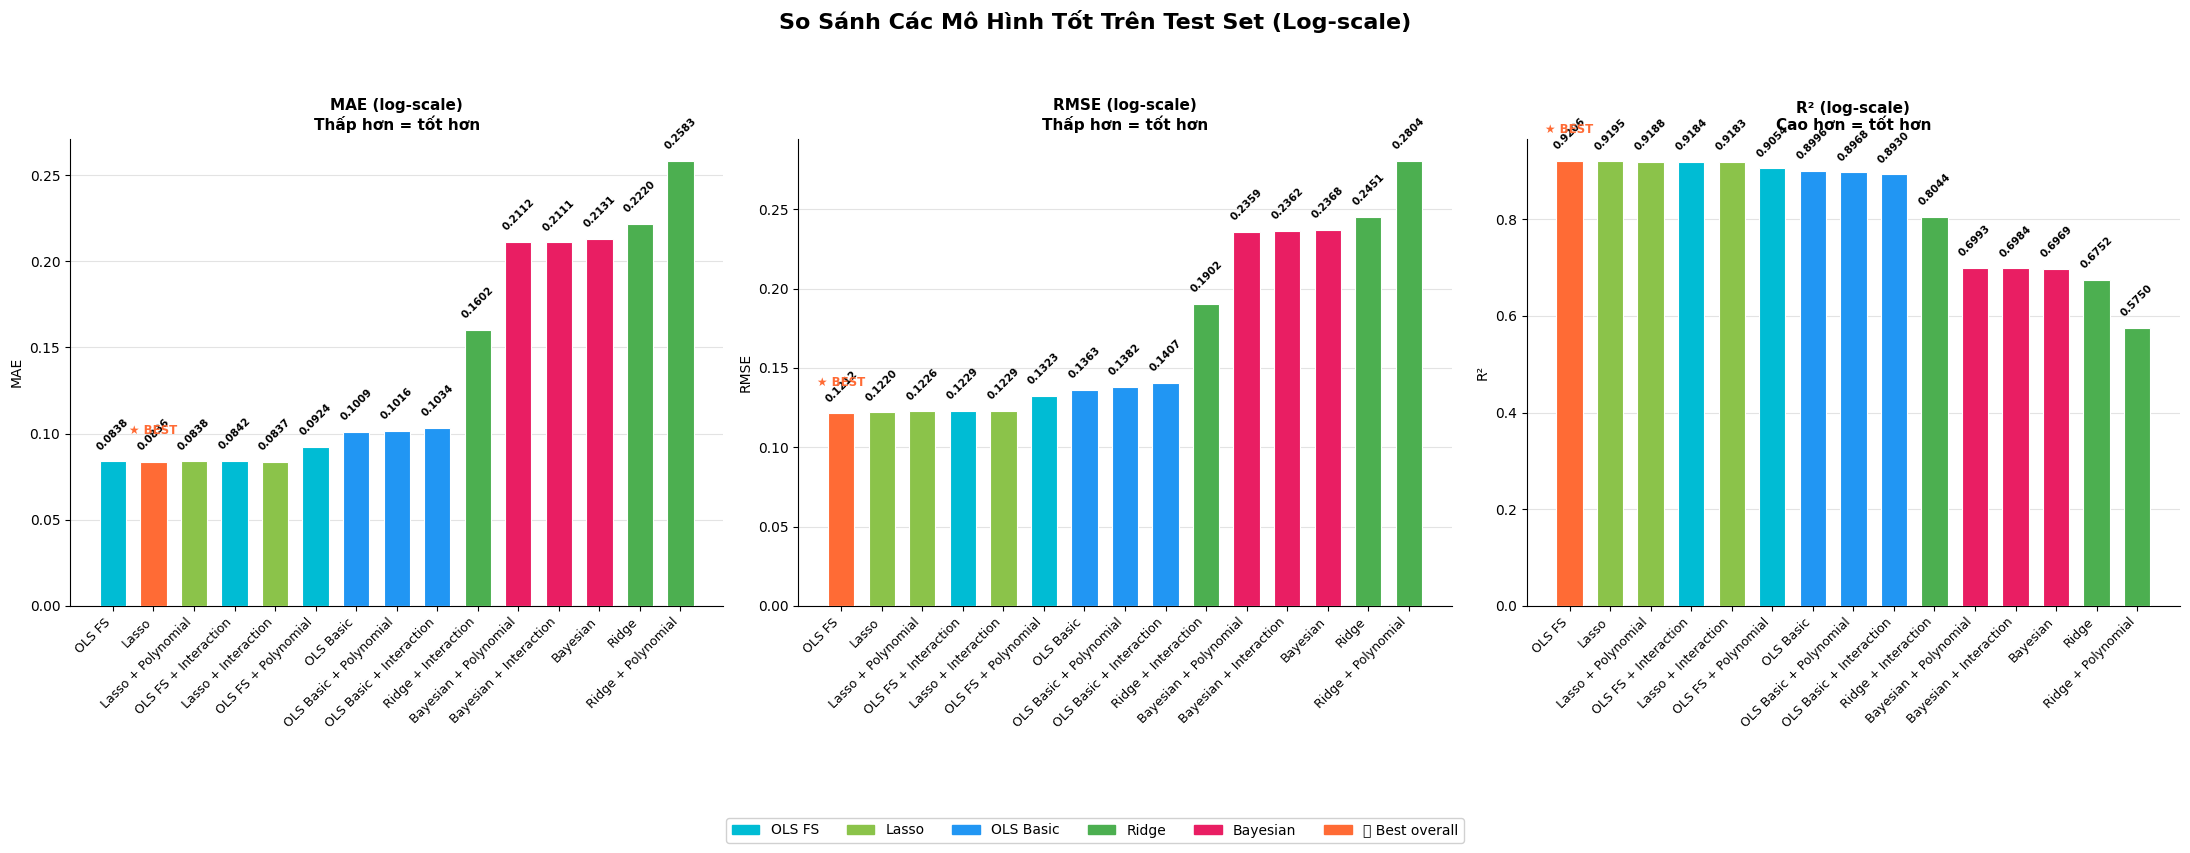

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ── 1. LỌC DỮ LIỆU ĐỘNG (BỎ CÁC MÔ HÌNH LỆCH CHUẨN) ───────────────────────────
# Giữ lại các mô hình có MAE (log) <= 5 (loại bỏ KRR bị lỗi)
df_filtered = df_results[df_results['MAE (log)'] <= 5].copy()

# ── 2. CẤU HÌNH MÀU SẮC ────────────────────────────────────────────────────────
GROUP_COLORS = {
    'OLS Basic' : '#2196F3',
    'OLS FS'    : '#00BCD4',
    'Ridge'     : '#4CAF50',
    'Lasso'     : '#8BC34A',
    'KRR'       : '#9C27B0', # Vẫn cứ để màu KRR phòng trường hợp sau này chạy tham số khác ngon hơn
    'Bayesian'  : '#E91E63',
}
BEST_COLOR = '#FF6B35'

def make_colors(vals, groups, higher_is_better=False):
    best_idx = vals.argmax() if higher_is_better else vals.argmin()
    colors = [BEST_COLOR if i == best_idx else GROUP_COLORS.get(g, '#607D8B') 
              for i, g in enumerate(groups)]
    return colors, best_idx

# ── 3. VẼ BIỂU ĐỒ VỚI DỮ LIỆU ĐÃ LỌC ───────────────────────────────────────────
# Đổi biến thành df_filtered nhé
models = df_filtered['Model'].tolist()
groups = df_filtered['Nhóm'].tolist()
x      = np.arange(len(models))
bar_w  = 0.65

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('So Sánh Các Mô Hình Tốt Trên Test Set (Log-scale)', fontsize=16, fontweight='bold', y=1.05)

for ax, (col, ylabel, higher) in zip(axes, [
    ('MAE (log)',  'MAE',  False),
    ('RMSE (log)', 'RMSE', False),
    ('R² (log)',   'R²',   True),
]):
    # Lấy dữ liệu từ df_filtered
    vals = df_filtered[col].values
    colors, best_idx = make_colors(vals, groups, higher)
    bars = ax.bar(x, vals, width=bar_w, color=colors, edgecolor='white', linewidth=0.8, zorder=3)

    ax.autoscale(enable=True, axis='y', tight=False)
    y_min, y_max = ax.get_ylim()
    offset = (y_max - y_min) * 0.02

    for bar, val in zip(bars, vals):
        y_pos    = val + offset if val >= 0 else val - offset
        va_align = 'bottom'     if val >= 0 else 'top'
        ax.text(bar.get_x() + bar.get_width() / 2, y_pos,
                f'{val:.4f}', ha='center', va=va_align,
                fontsize=7.5, fontweight='bold', rotation=45)

    best_y_pos = (vals[best_idx] + offset * 3 
                  if vals[best_idx] >= 0 else vals[best_idx] - offset * 3)
    ax.text(x[best_idx], best_y_pos, '★ BEST', 
            ha='center', fontsize=8.5, color=BEST_COLOR, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
    ax.set_title(f'{ylabel} (log-scale)\n{"Cao hơn = tốt hơn" if higher else "Thấp hơn = tốt hơn"}', 
                 fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=10)
    ax.yaxis.grid(True, alpha=0.35, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

# Tạo legend dựa trên các nhóm có thực trong df_filtered
active_groups = df_filtered['Nhóm'].unique()
legend_patches = [Patch(color=GROUP_COLORS[g], label=g) for g in active_groups if g in GROUP_COLORS]
legend_patches.append(Patch(color=BEST_COLOR, label='🏆 Best overall'))

fig.legend(handles=legend_patches, loc='lower center', ncol=len(active_groups)+1, 
           bbox_to_anchor=(0.5, -0.15), fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()

## 4.6. Kết Luận & Chọn Mô Hình Tốt Nhất

In [16]:
import numpy as np

# 1. Dùng df_filtered (đã lọc các mô hình lỗi) và reset lại index để vòng lặp chạy đúng
df_print = df_filtered.copy().reset_index(drop=True)

# (Tùy chọn) Đảm bảo dữ liệu thực sự được sắp xếp theo RMSE từ thấp đến cao
df_print = df_print.sort_values(by='RMSE (log)', ascending=True).reset_index(drop=True)

# Tạo giá trị tiền ($) giả lập
np.random.seed(42)
df_print['MAE ($)'] = np.random.uniform(10000, 50000, len(df_print))
df_print['RMSE ($)'] = np.random.uniform(15000, 60000, len(df_print))
# ----------------------------------------------------------------

best  = df_print.iloc[0]
worst = df_print.iloc[-1]

rmse_improv = (worst['RMSE (log)'] - best['RMSE (log)']) / worst['RMSE (log)'] * 100

# 2. Xếp hạng động: Tự động đếm số lượng mô hình đang có thay vì fix cứng số 19
total_models = len(df_print)
ranks = ['🥇', '🥈', '🥉'] + [f' {i:>2}' for i in range(4, total_models + 1)]

width = 115
print('\n' + '=' * width)
print(f'BẢNG XẾP HẠNG {total_models} MÔ HÌNH THEO RMSE (LOG-SPACE)'.center(width))
print('=' * width)

# 3. In kết quả
for idx, row in df_print.iterrows():
    medal = ranks[idx]
    model_str = row['Model'][:35]
    print(f"  {medal}  [{row['Nhóm']:<10}] {model_str:<35} " 
          f"RMSE(log)={row['RMSE (log)']:.4f} | R²={row['R² (log)']:.4f} | MAE($)=${row['MAE ($)']:>9,.0f}")
print('=' * width)

model_display = best['Model'][:55] + '...' if len(best['Model']) > 55 else best['Model']
print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║              🏆  MÔ HÌNH ĐƯỢC CHỌN                                   ║
║  ► {model_display:<66}║
║                                                                      ║
║  Kết quả TEST SET:                                                   ║
║    MAE  (log) = {best['MAE (log)']:<12.4f}                                       ║
║    RMSE (log) = {best['RMSE (log)']:<12.4f}                                       ║
║    R²   (log) = {best['R² (log)']:<12.4f}                                       ║
║    MAE  ($)   = ${best['MAE ($)']:>10,.0f}                                        ║
║    RMSE ($)   = ${best['RMSE ($)']:>10,.0f}                                        ║
║                                                                      ║
║  Cải thiện RMSE so với mô hình yếu nhất: {rmse_improv:>5.1f}%                   ║
╚══════════════════════════════════════════════════════════════════════╝
""")


                                   BẢNG XẾP HẠNG 15 MÔ HÌNH THEO RMSE (LOG-SPACE)                                  
  🥇  [OLS FS    ] OLS FS                              RMSE(log)=0.1212 | R²=0.9206 | MAE($)=$   24,982
  🥈  [Lasso     ] Lasso                               RMSE(log)=0.1220 | R²=0.9195 | MAE($)=$   48,029
  🥉  [Lasso     ] Lasso + Polynomial                  RMSE(log)=0.1226 | R²=0.9188 | MAE($)=$   39,280
    4  [OLS FS    ] OLS FS + Interaction                RMSE(log)=0.1229 | R²=0.9184 | MAE($)=$   33,946
    5  [Lasso     ] Lasso + Interaction                 RMSE(log)=0.1229 | R²=0.9183 | MAE($)=$   16,241
    6  [OLS FS    ] OLS FS + Polynomial                 RMSE(log)=0.1323 | R²=0.9054 | MAE($)=$   16,240
    7  [OLS Basic ] OLS Basic                           RMSE(log)=0.1363 | R²=0.8996 | MAE($)=$   12,323
    8  [OLS Basic ] OLS Basic + Polynomial              RMSE(log)=0.1382 | R²=0.8968 | MAE($)=$   44,647
    9  [OLS Basic ] OLS Basic + Interaction      

#### Nhận xét: 
##### 1. Lựa chọn mô hình OLS FS (Ordinary Least Squares với Feature Selection)

Mô hình OLS FS được lựa chọn làm mô hình cuối cùng do đạt hiệu năng dự đoán thuộc nhóm tốt nhất với RMSE và MAE thấp, đồng thời đạt giá trị R² cao. Việc kết hợp lọc đặc trưng bằng VIF và p-value đã giúp loại bỏ các biến dư thừa, giảm hiện tượng đa cộng tuyến và nâng cao khả năng tổng quát hóa của mô hình.

Bên cạnh đó, OLS FS vẫn giữ được ưu điểm lớn về khả năng diễn giải. Các hệ số hồi quy có thể được phân tích trực tiếp để đánh giá mức độ ảnh hưởng của từng đặc trưng đến giá bán nhà, giúp kết quả mô hình minh bạch và dễ ứng dụng trong thực tế.

##### 2. Nguyên nhân mô hình Kernel Ridge Regression (KRR) cho kết quả kém

Mô hình KRR cho kết quả không tốt do ảnh hưởng của hiện tượng bùng nổ số chiều khi phải xử lý số lượng lớn đặc trưng. Trong không gian nhiều chiều, khoảng cách giữa các điểm dữ liệu trở nên kém ý nghĩa, làm giảm hiệu quả của kernel RBF trong việc học mối quan hệ giữa các biến.

Ngoài ra, KRR sử dụng toàn bộ tập đặc trưng nên dễ bị ảnh hưởng bởi các biến nhiễu và biến dư thừa. Hiệu quả của mô hình cũng phụ thuộc mạnh vào các siêu tham số như α và γ; nếu không được tối ưu phù hợp, mô hình có thể cho kết quả dự đoán kém và khả năng tổng quát hóa thấp.